# Child Mortality Analysis
Predicting Under-5 Mortality Across Countries Using World Development Indicators
Group 5 of "Einführung in maschinelles Lernen" - A Data Science Project.

Ayoub Taychi

Hajar Lasri

Yama Saputra

# 1.1 Domain Problem
# Research Questions
## 1. Can ML regression models predict under-5 child mortality rates across countries using health, education, income, sanitation, and governance indicators from the WDI?
Justification: Under-5 mortality is a socially relevant and policy-important development outcome that is strongly linked to health, sanitation, income, and demographic conditions.

## 2. Can ML classifiers predict whether a country-year will fall into a high under-5 mortality risk group in the following year?
Justification: High risk is defined as the top 25% mortality-year under-5 mortality values, which creates a simple and interpretable binary target.

Technical Environment: Python v3.13.13 Importing data project libraries, pandas and scikit learn.

In [3]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pycountry") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pycountry"])

In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import pycountry

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"pycountry: {pycountry.__version__}")

pandas: 2.2.3
numpy: 1.26.4
matplotlib: 3.9.2
sklearn: 1.5.1
pycountry: 26.2.16


# Child Mortality Analysis
## Stage 1 — Data Preparation

This section prepares the WDI data for later analysis by:
- renaming key metadata fields,
- retaining countries only,
- selecting candidate indicators,
- reshaping the data into a country-year panel.

# Stage 1 — Data Preparation

In [7]:
df = pd.read_csv("WB_WDI_WIDEF (1).csv")
print(df.shape)
df.head()
df.info()
print(df.columns.tolist())

(295181, 107)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295181 entries, 0 to 295180
Columns: 107 entries, STRUCTURE to 2025
dtypes: float64(66), int64(2), object(39)
memory usage: 241.0+ MB
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'COMMENT_TS', 'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF', 'OBS_STATUS', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '19

In [8]:
df_prep = df.rename(columns={
    "REF_AREA": "country_code",
    "REF_AREA_LABEL": "country_name",
    "INDICATOR": "indicator_code",
    "INDICATOR_LABEL": "indicator_name"
}).copy()

df_prep[["country_code", "country_name", "indicator_code", "indicator_name"]].head()

,country_code,country_name,indicator_code,indicator_name
0,MNE,Montenegro,WB_WDI_IS_RRS_TOTL_KM,Rail lines (total route-km)
1,MMR,Myanmar,WB_WDI_ST_INT_XPND_CD,"International tourism, expenditures (current US$)"
2,LUX,Luxembourg,WB_WDI_SL_FAM_WORK_FE_ZS,"Contributing family workers, female (% of fema..."
3,NZL,New Zealand,WB_WDI_NY_TAX_NIND_KN,Taxes less subsidies on products (constant LCU)
4,KOR,"Korea, Rep.",WB_WDI_SE_TER_CUAT_ST_FE_ZS,"Educational attainment, at least completed sho..."


In [9]:
year_cols = [col for col in df_prep.columns if col.isdigit()]

print("Number of year columns:", len(year_cols))
print("First 5 years:", year_cols[:5])
print("Last 5 years:", year_cols[-5:])

Number of year columns: 66
First 5 years: ['1960', '1961', '1962', '1963', '1964']
Last 5 years: ['2021', '2022', '2023', '2024', '2025']


In [10]:
countries_table = (
    df_prep[["country_code", "country_name"]]
    .drop_duplicates()
    .sort_values(["country_name", "country_code"])
    .reset_index(drop=True)
)

print("Number of unique entities:", countries_table.shape[0])
countries_table.head(20)

Number of unique entities: 265


,country_code,country_name
0,AFG,Afghanistan
1,ALB,Albania
2,DZA,Algeria
3,ASM,American Samoa
4,AND,Andorra
5,AGO,Angola
6,ATG,Antigua and Barbuda
7,ARB,Arab World
8,ARG,Argentina
9,ARM,Armenia


- The code above defines the values in the countries table as "entities" as it also includes aggregation of countries and certain regions (ex. Europe, Afrika etc.)
- To restrict only to countries, it is necessary to sort the countries by filtering out the non-country values with Pycountry according to ISO 3 as seen in the code below.

In [12]:
iso3 = {c.alpha_3 for c in pycountry.countries} | {"XKX"}

countries_only_table = (
    countries_table[countries_table["country_code"].isin(iso3)]
    .copy()
    .sort_values(["country_name", "country_code"])
    .reset_index(drop=True)
)

print("Number of countries only:", countries_only_table.shape[0])
countries_only_table.head(20)

Number of countries only: 216


,country_code,country_name
0,AFG,Afghanistan
1,ALB,Albania
2,DZA,Algeria
3,ASM,American Samoa
4,AND,Andorra
5,AGO,Angola
6,ATG,Antigua and Barbuda
7,ARG,Argentina
8,ARM,Armenia
9,ABW,Aruba


In [13]:
indicators_table = (
    df_prep[["indicator_code", "indicator_name"]]
    .drop_duplicates()
    .sort_values(["indicator_name", "indicator_code"])
    .reset_index(drop=True)
)

print("Number of unique indicators:", indicators_table.shape[0])
indicators_table.head(20)

Number of unique indicators: 1516


,indicator_code,indicator_name
0,WB_WDI_SH_STA_ARIC_ZS,ARI treatment (% of children under 5 taken to ...
1,WB_WDI_EG_CFT_ACCS_ZS,Access to clean fuels and technologies for coo...
2,WB_WDI_EG_CFT_ACCS_RU_ZS,Access to clean fuels and technologies for coo...
3,WB_WDI_EG_CFT_ACCS_UR_ZS,Access to clean fuels and technologies for coo...
4,WB_WDI_EG_ELC_ACCS_ZS,Access to electricity (% of population)
5,WB_WDI_EG_ELC_ACCS_RU_ZS,"Access to electricity, rural (% of rural popul..."
6,WB_WDI_EG_ELC_ACCS_UR_ZS,"Access to electricity, urban (% of urban popul..."
7,WB_WDI_FX_OWN_TOTL_ZS,Account ownership at a financial institution o...
8,WB_WDI_FX_OWN_TOTL_FE_ZS,Account ownership at a financial institution o...
9,WB_WDI_FX_OWN_TOTL_MA_ZS,Account ownership at a financial institution o...


- The cell above shows that there are 1,489 unique indicators in the dataset. Which are nto all relevant to answering our reseach questions. Hence it is necessary to filter this down to the specific indicator(s) related to under-5 mortality rate for our analysis.

### Determining relevant indicators for this topic

In [16]:
keywords = [
    "under-5",
    "mortality",
    "gdp per capita",
    "gini",
    "health expenditure",
    "physicians",
    "immunization",
    "water",
    "sanitation",
    "electricity",
    "primary completion",
    "literacy",
    "rule of law",
    "government effectiveness",
    "fertility",
    "urban population",
    "population ages 0-14",
    "life expectancy"
]

for kw in keywords:
    print(f"\n========== {kw.upper()} ==========")
    display(
        indicators_table[
            indicators_table["indicator_name"].str.contains(kw, case=False, na=False)
        ].head(20)
    )


========== UNDER-5 ==========


,indicator_code,indicator_name
858,WB_WDI_SH_DYN_MORT,"Mortality rate, under-5 (per 1,000 live births)"
859,WB_WDI_SH_DYN_MORT_FE,"Mortality rate, under-5, female (per 1,000 liv..."
860,WB_WDI_SH_DYN_MORT_MA,"Mortality rate, under-5, male (per 1,000 live ..."
1485,WB_WDI_SH_MLR_NETS_ZS,Use of insecticide-treated bed nets (% of unde...



========== MORTALITY ==========


,indicator_code,indicator_name
792,WB_WDI_SH_STA_MMRT,"Maternal mortality ratio (modeled estimate, pe..."
793,WB_WDI_SH_STA_MMRT_NE,"Maternal mortality ratio (national estimate, p..."
841,WB_WDI_SH_STA_TRAF_P5,Mortality caused by road traffic injury (per 1...
842,WB_WDI_SH_DYN_NCOM_ZS,"Mortality from CVD, cancer, diabetes or CRD be..."
843,WB_WDI_SH_DYN_NCOM_FE_ZS,"Mortality from CVD, cancer, diabetes or CRD be..."
844,WB_WDI_SH_DYN_NCOM_MA_ZS,"Mortality from CVD, cancer, diabetes or CRD be..."
845,WB_WDI_SH_STA_AIRP_P5,Mortality rate attributed to household and amb...
846,WB_WDI_SH_STA_AIRP_FE_P5,Mortality rate attributed to household and amb...
847,WB_WDI_SH_STA_AIRP_MA_P5,Mortality rate attributed to household and amb...
848,WB_WDI_SH_STA_POIS_P5,Mortality rate attributed to unintentional poi...



========== GDP PER CAPITA ==========


...

,indicator_code,indicator_name
3,WB_WDI_EG_CFT_ACCS_UR_ZS,Access to clean fuels and technologies for coo...
6,WB_WDI_EG_ELC_ACCS_UR_ZS,"Access to electricity, urban (% of urban popul..."
1044,WB_WDI_SH_STA_ODFC_UR_ZS,"People practicing open defecation, urban (% of..."
1047,WB_WDI_SH_H2O_BASW_UR_ZS,People using at least basic drinking water ser...
1050,WB_WDI_SH_STA_BASS_UR_ZS,People using at least basic sanitation service...
1053,WB_WDI_SH_H2O_SMDW_UR_ZS,People using safely managed drinking water ser...
1056,WB_WDI_SH_STA_SMSS_UR_ZS,People using safely managed sanitation service...
1059,WB_WDI_SH_STA_HYGN_UR_ZS,People with basic handwashing facilities inclu...
1134,WB_WDI_EN_URB_LCTY_UR_ZS,Population in the largest city (% of urban pop...
1138,WB_WDI_EN_POP_SLUM_UR_ZS,Population living in slums (% of urban populat...



========== POPULATION AGES 0-14 ==========


,indicator_code,indicator_name
1079,WB_WDI_SP_POP_0014_TO_ZS,Population ages 0-14 (% of total population)
1080,WB_WDI_SP_POP_0014_FE_IN,"Population ages 0-14, female"
1081,WB_WDI_SP_POP_0014_FE_ZS,"Population ages 0-14, female (% of female popu..."
1082,WB_WDI_SP_POP_0014_MA_IN,"Population ages 0-14, male"
1083,WB_WDI_SP_POP_0014_MA_ZS,"Population ages 0-14, male (% of male population)"
1084,WB_WDI_SP_POP_0014_TO,"Population ages 0-14, total"



========== LIFE EXPECTANCY ==========


,indicator_code,indicator_name
749,WB_WDI_SP_DYN_LE00_FE_IN,"Life expectancy at birth, female (years)"
750,WB_WDI_SP_DYN_LE00_MA_IN,"Life expectancy at birth, male (years)"
751,WB_WDI_SP_DYN_LE00_IN,"Life expectancy at birth, total (years)"


## Candidate Indicator Selection

- We do not use the full WDI indicator universe.  
- Instead, we define a broader candidate set based on theoretical relevance to child mortality, including health, income, sanitation, infrastructure, and demographic variables.

In [18]:
candidate_indicator_dict = {
    "u5mr": "WB_WDI_SH_DYN_MORT",

    "gdp_pc_constant_2015_usd": "WB_WDI_NY_GDP_PCAP_KD",
    "gdp_pc_ppp_current": "WB_WDI_NY_GDP_PCAP_PP_CD",
    "gini": "WB_WDI_SI_POV_GINI",

    "health_exp_pct_gdp": "WB_WDI_SH_XPD_CHEX_GD_ZS",
    "physicians_per_1000": "WB_WDI_SH_MED_PHYS_ZS",
    "dpt": "WB_WDI_SH_IMM_IDPT",
    "measles": "WB_WDI_SH_IMM_MEAS",
    "life_expectancy": "WB_WDI_SP_DYN_LE00_IN",
    "neonatal_mortality": "WB_WDI_SH_DYN_NMRT",

    "water_basic": "WB_WDI_SH_H2O_BASW_ZS",
    "water_safe": "WB_WDI_SH_H2O_SMDW_ZS",
    "sanitation_basic": "WB_WDI_SH_STA_BASS_ZS",
    "sanitation_safe": "WB_WDI_SH_STA_SMSS_ZS",
    "electricity": "WB_WDI_EG_ELC_ACCS_ZS",

    "primary_completion": "WB_WDI_SE_PRM_CMPT_ZS",
    "adult_literacy": "WB_WDI_SE_ADT_LITR_ZS",
    "rule_of_law": "WB_WDI_RL_EST",
    "govt_effectiveness": "WB_WDI_GE_EST",

    "fertility": "WB_WDI_SP_DYN_TFRT_IN",
    "urban_pct": "WB_WDI_SP_URB_TOTL_IN_ZS",
    "urban_population_total": "WB_WDI_SP_URB_TOTL",
    "population_total": "WB_WDI_SP_POP_TOTL",
    "pop_0_14_pct": "WB_WDI_SP_POP_0014_TO_ZS",
}

print("Number of candidate indicators:", len(candidate_indicator_dict))
print(list(candidate_indicator_dict.keys()))

Number of candidate indicators: 24
['u5mr', 'gdp_pc_constant_2015_usd', 'gdp_pc_ppp_current', 'gini', 'health_exp_pct_gdp', 'physicians_per_1000', 'dpt', 'measles', 'life_expectancy', 'neonatal_mortality', 'water_basic', 'water_safe', 'sanitation_basic', 'sanitation_safe', 'electricity', 'primary_completion', 'adult_literacy', 'rule_of_law', 'govt_effectiveness', 'fertility', 'urban_pct', 'urban_population_total', 'population_total', 'pop_0_14_pct']


In [19]:
candidate_indicators_table = pd.DataFrame({
    "new_name": list(candidate_indicator_dict.keys()),
    "indicator_code": list(candidate_indicator_dict.values())
})

candidate_indicators_table = candidate_indicators_table.merge(
    indicators_table,
    on="indicator_code",
    how="left"
).sort_values("new_name").reset_index(drop=True)

candidate_indicators_table

,new_name,indicator_code,indicator_name
0,adult_literacy,WB_WDI_SE_ADT_LITR_ZS,"Literacy rate, adult total (% of people ages 1..."
1,dpt,WB_WDI_SH_IMM_IDPT,"Immunization, DPT (% of children ages 12-23 mo..."
2,electricity,WB_WDI_EG_ELC_ACCS_ZS,Access to electricity (% of population)
3,fertility,WB_WDI_SP_DYN_TFRT_IN,"Fertility rate, total (births per woman)"
4,gdp_pc_constant_2015_usd,WB_WDI_NY_GDP_PCAP_KD,GDP per capita (constant 2015 US$)
5,gdp_pc_ppp_current,WB_WDI_NY_GDP_PCAP_PP_CD,"GDP per capita, PPP (current international $)"
6,gini,WB_WDI_SI_POV_GINI,Gini index
7,govt_effectiveness,WB_WDI_GE_EST,Government Effectiveness: Estimate
8,health_exp_pct_gdp,WB_WDI_SH_XPD_CHEX_GD_ZS,Current health expenditure (% of GDP)
9,life_expectancy,WB_WDI_SP_DYN_LE00_IN,"Life expectancy at birth, total (years)"


In [20]:
keep_cols = ["country_code", "country_name", "indicator_code", "indicator_name"] + year_cols
df_stage1 = df_prep[keep_cols].copy()

print("Initial stage1 shape:", df_stage1.shape)
df_stage1.head(10)

Initial stage1 shape: (295181, 70)


,country_code,country_name,indicator_code,indicator_name,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,MNE,Montenegro,WB_WDI_IS_RRS_TOTL_KM,Rail lines (total route-km),NaN,NaN,NaN,NaN,NaN,NaN,...,2.490000e+02,2.490000e+02,2.490000e+02,2.500000e+02,NaN,NaN,NaN,NaN,NaN,NaN
1,MMR,Myanmar,WB_WDI_ST_INT_XPND_CD,"International tourism, expenditures (current US$)",NaN,NaN,NaN,NaN,NaN,NaN,...,2.010000e+08,1.360000e+08,1.180000e+08,2.140000e+08,NaN,NaN,NaN,NaN,NaN,NaN
2,LUX,Luxembourg,WB_WDI_SL_FAM_WORK_FE_ZS,"Contributing family workers, female (% of fema...",NaN,NaN,NaN,NaN,NaN,NaN,...,1.394918e+00,9.868241e-01,8.426004e-01,1.478158e+00,1.654600e+00,1.686016e+00,2.180262e+00,1.688659e+00,1.988782,1.98045
3,NZL,New Zealand,WB_WDI_NY_TAX_NIND_KN,Taxes less subsidies on products (constant LCU),NaN,NaN,NaN,NaN,NaN,NaN,...,2.453566e+10,2.549904e+10,2.645277e+10,2.701978e+10,2.642800e+10,2.788406e+10,2.952042e+10,2.952592e+10,NaN,NaN
4,KOR,"Korea, Rep.",WB_WDI_SE_TER_CUAT_ST_FE_ZS,"Educational attainment, at least completed sho...",NaN,NaN,NaN,NaN,NaN,NaN,...,3.735632e+01,3.831938e+01,3.941874e+01,4.034009e+01,4.086267e+01,4.145240e+01,4.228944e+01,4.345861e+01,44.547663,NaN
5,GNB,Guinea-Bissau,WB_WDI_SH_DTH_0509,Number of deaths ages 5-9 years,NaN,NaN,NaN,NaN,NaN,NaN,...,4.740000e+02,4.530000e+02,4.350000e+02,4.210000e+02,4.080000e+02,3.960000e+02,3.820000e+02,3.710000e+02,NaN,NaN
6,LBR,Liberia,WB_WDI_DC_DAC_LUXL_CD,"Net bilateral aid flows from DAC donors, Luxem...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,DNK,Denmark,WB_WDI_EN_GHG_CH4_FE_MT_CE_AR5,Methane (CH4) emissions from Fugitive Emission...,NaN,NaN,NaN,NaN,NaN,NaN,...,4.455000e-01,4.596000e-01,4.609000e-01,4.523000e-01,4.321000e-01,4.486000e-01,4.683000e-01,4.827000e-01,0.504500,NaN
8,SMR,San Marino,WB_WDI_BM_GSR_TOTL_CD,"Imports of goods, services and primary income ...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.540829e+09,2.800577e+09,2.631837e+09,2.470865e+09,3.238489e+09,3.446677e+09,3.470362e+09,NaN,NaN
9,SMR,San Marino,WB_WDI_NY_GDP_MKTP_KD_ZG,GDP growth (annual %),NaN,NaN,NaN,NaN,NaN,NaN,...,2.344406e+00,2.582655e-01,1.493905e+00,2.065685e+00,-6.647911e+00,1.389779e+01,7.898441e+00,4.019349e-01,NaN,NaN


In [21]:
country_codes_only = set(countries_only_table["country_code"])

df_stage1 = df_stage1[df_stage1["country_code"].isin(country_codes_only)].copy()

print("Shape after countries-only filter:", df_stage1.shape)
print("Unique countries:", df_stage1["country_code"].nunique())

Shape after countries-only filter: (251650, 70)
Unique countries: 216


In [22]:
df_stage1 = df_stage1[df_stage1["indicator_code"].isin(candidate_indicator_dict.values())].copy()

print("Shape after candidate-indicator filter:", df_stage1.shape)
print("Unique indicators kept:", df_stage1["indicator_code"].nunique())
sorted(df_stage1["indicator_code"].unique())

Shape after candidate-indicator filter: (4779, 70)
Unique indicators kept: 24


['WB_WDI_EG_ELC_ACCS_ZS',
 'WB_WDI_GE_EST',
 'WB_WDI_NY_GDP_PCAP_KD',
 'WB_WDI_NY_GDP_PCAP_PP_CD',
 'WB_WDI_RL_EST',
 'WB_WDI_SE_ADT_LITR_ZS',
 'WB_WDI_SE_PRM_CMPT_ZS',
 'WB_WDI_SH_DYN_MORT',
 'WB_WDI_SH_DYN_NMRT',
 'WB_WDI_SH_H2O_BASW_ZS',
 'WB_WDI_SH_H2O_SMDW_ZS',
 'WB_WDI_SH_IMM_IDPT',
 'WB_WDI_SH_IMM_MEAS',
 'WB_WDI_SH_MED_PHYS_ZS',
 'WB_WDI_SH_STA_BASS_ZS',
 'WB_WDI_SH_STA_SMSS_ZS',
 'WB_WDI_SH_XPD_CHEX_GD_ZS',
 'WB_WDI_SI_POV_GINI',
 'WB_WDI_SP_DYN_LE00_IN',
 'WB_WDI_SP_DYN_TFRT_IN',
 'WB_WDI_SP_POP_0014_TO_ZS',
 'WB_WDI_SP_POP_TOTL',
 'WB_WDI_SP_URB_TOTL',
 'WB_WDI_SP_URB_TOTL_IN_ZS']

In [23]:
inverse_indicator_map = {v: k for k, v in candidate_indicator_dict.items()}

print("Inverse map size:", len(inverse_indicator_map))
list(inverse_indicator_map.items())[:5]

Inverse map size: 24


[('WB_WDI_SH_DYN_MORT', 'u5mr'),
 ('WB_WDI_NY_GDP_PCAP_KD', 'gdp_pc_constant_2015_usd'),
 ('WB_WDI_NY_GDP_PCAP_PP_CD', 'gdp_pc_ppp_current'),
 ('WB_WDI_SI_POV_GINI', 'gini'),
 ('WB_WDI_SH_XPD_CHEX_GD_ZS', 'health_exp_pct_gdp')]

In [24]:
long_df = df_stage1.melt(
    id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

long_df["year"] = long_df["year"].astype(int)
long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

print("long_df shape:", long_df.shape)
display(long_df.head(10))

long_df shape: (315414, 6)


,country_code,country_name,indicator_code,indicator_name,year,value
0,GMB,"Gambia, The",WB_WDI_NY_GDP_PCAP_PP_CD,"GDP per capita, PPP (current international $)",1960,NaN
1,KAZ,Kazakhstan,WB_WDI_SH_DYN_NMRT,"Mortality rate, neonatal (per 1,000 live births)",1960,NaN
2,PNG,Papua New Guinea,WB_WDI_SH_DYN_NMRT,"Mortality rate, neonatal (per 1,000 live births)",1960,NaN
3,NAM,Namibia,WB_WDI_SH_DYN_MORT,"Mortality rate, under-5 (per 1,000 live births)",1960,NaN
4,ETH,Ethiopia,WB_WDI_SP_DYN_LE00_IN,"Life expectancy at birth, total (years)",1960,39.615
5,TJK,Tajikistan,WB_WDI_NY_GDP_PCAP_KD,GDP per capita (constant 2015 US$),1960,NaN
6,LUX,Luxembourg,WB_WDI_SE_PRM_CMPT_ZS,"Primary completion rate, total (% of relevant ...",1960,NaN
7,COM,Comoros,WB_WDI_SH_XPD_CHEX_GD_ZS,Current health expenditure (% of GDP),1960,NaN
8,KIR,Kiribati,WB_WDI_SP_DYN_LE00_IN,"Life expectancy at birth, total (years)",1960,47.958
9,ZMB,Zambia,WB_WDI_NY_GDP_PCAP_PP_CD,"GDP per capita, PPP (current international $)",1960,NaN


In [25]:
long_df["indicator_short"] = long_df["indicator_code"].map(inverse_indicator_map)

print("Missing short names:", long_df["indicator_short"].isna().sum())
display(
    long_df[["indicator_code", "indicator_short"]]
    .drop_duplicates()
    .sort_values("indicator_short")
    .head(30)
)

Missing short names: 0


,indicator_code,indicator_short
15,WB_WDI_SE_ADT_LITR_ZS,adult_literacy
63,WB_WDI_SH_IMM_IDPT,dpt
14,WB_WDI_EG_ELC_ACCS_ZS,electricity
40,WB_WDI_SP_DYN_TFRT_IN,fertility
5,WB_WDI_NY_GDP_PCAP_KD,gdp_pc_constant_2015_usd
0,WB_WDI_NY_GDP_PCAP_PP_CD,gdp_pc_ppp_current
94,WB_WDI_SI_POV_GINI,gini
10,WB_WDI_GE_EST,govt_effectiveness
7,WB_WDI_SH_XPD_CHEX_GD_ZS,health_exp_pct_gdp
4,WB_WDI_SP_DYN_LE00_IN,life_expectancy


In [26]:
dup_long = long_df.duplicated(
    subset=["country_code", "country_name", "year", "indicator_short"]
).sum()

print("Duplicate country-year-indicator rows before pivot:", dup_long)

if dup_long > 0:
    display(
        long_df[
            long_df.duplicated(
                subset=["country_code", "country_name", "year", "indicator_short"],
                keep=False
            )
        ].sort_values(["country_name", "year", "indicator_short"]).head(20)
    )

Duplicate country-year-indicator rows before pivot: 0


In [27]:
assert dup_long == 0, "Resolve duplicates before pivoting."

panel_candidate = long_df.pivot(
    index=["country_code", "country_name", "year"],
    columns="indicator_short",
    values="value"
).reset_index()

panel_candidate.columns.name = None

print("panel_candidate shape:", panel_candidate.shape)
display(panel_candidate.head(10))

panel_candidate shape: (14256, 27)


,country_code,country_name,year,adult_literacy,dpt,electricity,fertility,gdp_pc_constant_2015_usd,gdp_pc_ppp_current,gini,...,population_total,primary_completion,rule_of_law,sanitation_basic,sanitation_safe,u5mr,urban_pct,urban_population_total,water_basic,water_safe
0,ABW,Aruba,1960,NaN,NaN,NaN,4.567,NaN,NaN,NaN,...,54922.0,NaN,NaN,NaN,NaN,NaN,59.023670,32417.0,NaN,NaN
1,ABW,Aruba,1961,NaN,NaN,NaN,4.422,NaN,NaN,NaN,...,55578.0,NaN,NaN,NaN,NaN,NaN,59.072800,32831.0,NaN,NaN
2,ABW,Aruba,1962,NaN,NaN,NaN,4.262,NaN,NaN,NaN,...,56320.0,NaN,NaN,NaN,NaN,NaN,59.212271,33348.0,NaN,NaN
3,ABW,Aruba,1963,NaN,NaN,NaN,4.107,NaN,NaN,NaN,...,57002.0,NaN,NaN,NaN,NaN,NaN,59.432359,33878.0,NaN,NaN
4,ABW,Aruba,1964,NaN,NaN,NaN,3.940,NaN,NaN,NaN,...,57619.0,NaN,NaN,NaN,NaN,NaN,59.723340,34412.0,NaN,NaN
5,ABW,Aruba,1965,NaN,NaN,NaN,3.797,NaN,NaN,NaN,...,58190.0,NaN,NaN,NaN,NaN,NaN,60.075491,34958.0,NaN,NaN
6,ABW,Aruba,1966,NaN,NaN,NaN,3.621,NaN,NaN,NaN,...,58694.0,NaN,NaN,NaN,NaN,NaN,60.479087,35498.0,NaN,NaN
7,ABW,Aruba,1967,NaN,NaN,NaN,3.452,NaN,NaN,NaN,...,58990.0,NaN,NaN,NaN,NaN,NaN,60.924404,35939.0,NaN,NaN
8,ABW,Aruba,1968,NaN,NaN,NaN,3.277,NaN,NaN,NaN,...,59069.0,NaN,NaN,NaN,NaN,NaN,61.401720,36269.0,NaN,NaN
9,ABW,Aruba,1969,NaN,NaN,NaN,3.111,NaN,NaN,NaN,...,59052.0,NaN,NaN,NaN,NaN,NaN,61.901310,36554.0,NaN,NaN


In [28]:
df_stage1.to_csv("stage1_filtered_raw.csv", index=False)
long_df.to_csv("stage1_long.csv", index=False)
panel_candidate.to_csv("stage1_panel_candidate_full_horizon.csv", index=False)

print("Stage 1 files saved successfully.")

Stage 1 files saved successfully.


#  End of Stage 1
The raw WDI data were prepared into a country-year candidate panel by:
- renaming key metadata columns,
- keeping countries only,
- selecting a broader candidate indicator set,
- reshaping the data from wide format to long format,
- and building a country-year panel for the full available time horizon.

No final time restriction has been applied yet. The choice of the final modeling window will be justified in Stage 2 using data quality, missingness, and coverage analysis.

# Stage 2 = Data Cleaning + Data Quality Audit + Early EDA 
## Checking for data consistency and missing values

In [31]:
dup_count = panel_candidate.duplicated(subset=["country_code", "year"]).sum()

print("Duplicate country-year rows:", dup_count)

Duplicate country-year rows: 0


In [32]:
missing_report = pd.DataFrame({
    "missing_count": panel_candidate.isna().sum(),
    "missing_pct": (panel_candidate.isna().mean() * 100)
}).sort_values("missing_pct", ascending=False)

missing_report

,missing_count,missing_pct
adult_literacy,13149,92.234848
gini,11854,83.150954
sanitation_safe,10687,74.964927
water_safe,10540,73.933782
health_exp_pct_gdp,9694,67.999439
primary_completion,9485,66.533389
govt_effectiveness,9292,65.179574
rule_of_law,9178,64.379910
sanitation_basic,9090,63.762626
water_basic,9047,63.460999


In [33]:
target_coverage_by_year = (
    panel_candidate.groupby("year")["u5mr"]
    .apply(lambda s: s.notna().sum())
    .reset_index(name="u5mr_non_missing_countries")
)

target_coverage_by_year.head(66)

,year,u5mr_non_missing_countries
0,1960,128
1,1961,129
2,1962,131
3,1963,134
4,1964,137
...,...,...
61,2021,196
62,2022,196
63,2023,196
64,2024,0


In [34]:
predictor_cols = [
    "gdp_pc_constant_2015_usd",
    "gdp_pc_ppp_current",
    "gini",
    "health_exp_pct_gdp",
    "physicians_per_1000",
    "dpt",
    "measles",
    "life_expectancy",
    "neonatal_mortality",
    "water_basic",
    "water_safe",
    "sanitation_basic",
    "sanitation_safe",
    "electricity",
    "primary_completion",
    "adult_literacy",
    "rule_of_law",
    "govt_effectiveness",
    "fertility",
    "urban_pct",
    "urban_population_total",
    "population_total",
    "pop_0_14_pct"
]

predictor_coverage_by_year = panel_candidate.groupby("year")[predictor_cols].apply(
    lambda df: df.notna().sum()
)

predictor_coverage_by_year.head(20)

,gdp_pc_constant_2015_usd,gdp_pc_ppp_current,gini,health_exp_pct_gdp,physicians_per_1000,dpt,measles,life_expectancy,neonatal_mortality,water_basic,...,electricity,primary_completion,adult_literacy,rule_of_law,govt_effectiveness,fertility,urban_pct,urban_population_total,population_total,pop_0_14_pct
year,,,,,,,,,,,,,,,,,,,,,
1960,107,0,0,0,136,0,0,214,49,0,...,0,0,0,0,0,215,216,215,215,216
1961,112,0,0,0,18,0,0,215,50,0,...,0,0,0,0,0,214,216,215,215,216
1962,112,0,0,0,16,0,0,215,50,0,...,0,0,0,0,0,215,216,215,215,216
1963,112,0,1,0,16,0,0,214,53,0,...,0,0,0,0,0,214,216,215,215,216
1964,112,0,1,0,16,0,0,214,57,0,...,0,0,0,0,0,215,216,215,215,216
1965,114,0,1,0,108,0,0,214,64,0,...,0,0,0,0,0,215,216,215,215,216
1966,117,0,1,0,19,0,0,215,65,0,...,0,0,0,0,0,215,216,215,215,216
1967,118,0,1,0,17,0,0,215,67,0,...,0,0,0,0,0,215,216,215,215,216
1968,118,0,2,0,17,0,0,215,77,0,...,0,0,0,0,0,215,216,215,215,216


In [35]:
core_candidate_cols = [
    "u5mr",
    "gdp_pc_constant_2015_usd",
    "health_exp_pct_gdp",
    "dpt",
    "measles",
    "water_basic",
    "sanitation_basic",
    "electricity",
    "fertility",
    "urban_pct",
    "pop_0_14_pct"
]

joint_core_by_year = (
    panel_candidate.groupby("year")
    .apply(lambda df: pd.Series({
        "n_countries_total": df["country_code"].nunique(),
        "n_complete_core_rows": df[core_candidate_cols].notna().all(axis=1).sum()
    }))
    .reset_index()
)

joint_core_by_year["complete_core_pct"] = (
    100 * joint_core_by_year["n_complete_core_rows"] / joint_core_by_year["n_countries_total"]
)

joint_core_by_year.head(20)

C:\Users\ayoub\AppData\Local\Temp\ipykernel_27832\470281583.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,year,n_countries_total,n_complete_core_rows,complete_core_pct
0,1960,216,0,0.0
1,1961,216,0,0.0
2,1962,216,0,0.0
3,1963,216,0,0.0
4,1964,216,0,0.0
5,1965,216,0,0.0
6,1966,216,0,0.0
7,1967,216,0,0.0
8,1968,216,0,0.0
9,1969,216,0,0.0


In [36]:
joint_core_by_year.tail(20)

,year,n_countries_total,n_complete_core_rows,complete_core_pct
46,2006,216,182,84.259259
47,2007,216,183,84.722222
48,2008,216,184,85.185185
49,2009,216,184,85.185185
50,2010,216,185,85.648148
51,2011,216,186,86.111111
52,2012,216,185,85.648148
53,2013,216,188,87.037037
54,2014,216,188,87.037037
55,2015,216,188,87.037037


In [37]:
print("First year with > 0 complete core rows:",
      joint_core_by_year.loc[joint_core_by_year["n_complete_core_rows"] > 0, "year"].min())

print("First year with >= 50% complete core rows:",
      joint_core_by_year.loc[joint_core_by_year["complete_core_pct"] >= 50, "year"].min())

print("First year with >= 70% complete core rows:",
      joint_core_by_year.loc[joint_core_by_year["complete_core_pct"] >= 70, "year"].min())

print("First year with >= 80% complete core rows:",
      joint_core_by_year.loc[joint_core_by_year["complete_core_pct"] >= 80, "year"].min())

First year with > 0 complete core rows: 2000
First year with >= 50% complete core rows: 2000
First year with >= 70% complete core rows: 2000
First year with >= 80% complete core rows: 2001


In [38]:
joint_core_by_year[
    (joint_core_by_year["year"] >= 1990) &
    (joint_core_by_year["year"] <= 2025)
]

,year,n_countries_total,n_complete_core_rows,complete_core_pct
30,1990,216,0,0.000000
31,1991,216,0,0.000000
32,1992,216,0,0.000000
33,1993,216,0,0.000000
34,1994,216,0,0.000000
35,1995,216,0,0.000000
36,1996,216,0,0.000000
37,1997,216,0,0.000000
38,1998,216,0,0.000000
39,1999,216,0,0.000000


## Time-Window Decision

- We explored the full 1960–2025 horizon, but joint completeness for the target and the core predictors is effectively zero before 2000.

- From 2000 onward, the candidate panel becomes usable and remains stable through 2023.

- Therefore, the final modeling window will be restricted to 2000–2023.

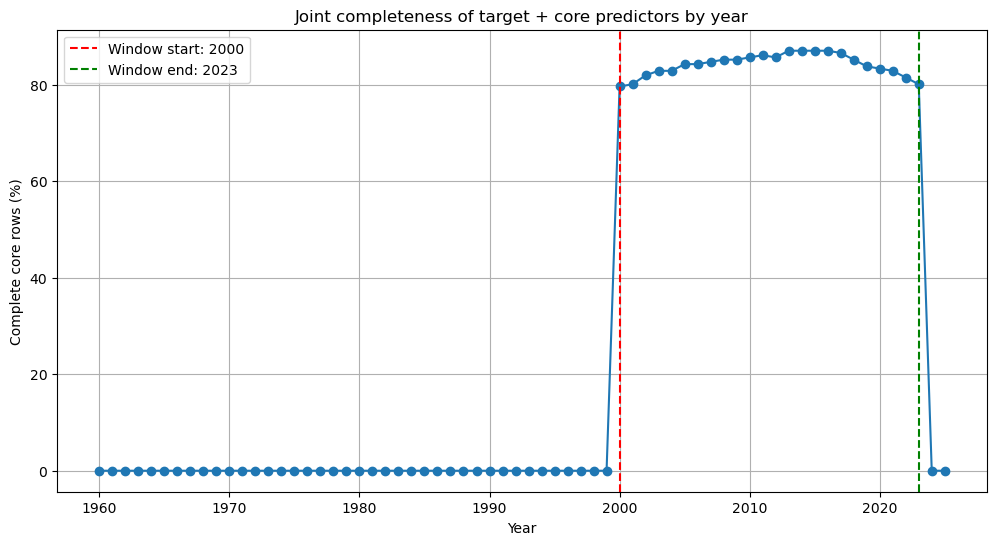

In [40]:

plt.figure(figsize=(12, 6))
plt.plot(
    joint_core_by_year["year"],
    joint_core_by_year["complete_core_pct"],
    marker="o"
)

plt.axvline(2000, linestyle="--", color="red", label="Window start: 2000")
plt.axvline(2023, linestyle="--", color="green", label="Window end: 2023")
plt.legend(fontsize=10)

plt.title("Joint completeness of target + core predictors by year")
plt.xlabel("Year")
plt.ylabel("Complete core rows (%)")
plt.grid(True)
plt.show()

- This time-series visualization provides evidence to restrict modeling to 2000 - 2023 by showing the incompleteness of data before the year 2000 and becomes stable from 2000 onwards.

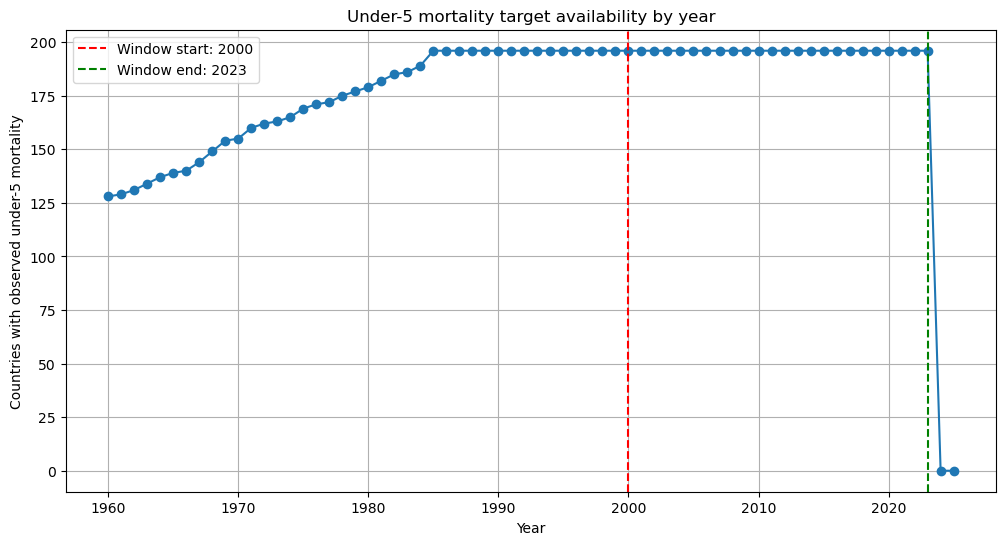

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(
    target_coverage_by_year["year"],
    target_coverage_by_year["u5mr_non_missing_countries"],
    marker="o"
)

plt.axvline(2000, linestyle="--", color="red", label="Window start: 2000")
plt.axvline(2023, linestyle="--", color="green", label="Window end: 2023")
plt.legend(fontsize=10)

plt.title("Under-5 mortality target availability by year")
plt.xlabel("Year")
plt.ylabel("Countries with observed under-5 mortality")
plt.grid(True)
plt.show()

In [43]:
panel_modern = panel_candidate[
    (panel_candidate["year"] >= 2000) &
    (panel_candidate["year"] <= 2023)
].copy()

print("Modern panel shape:", panel_modern.shape)
print("Year range:", panel_modern["year"].min(), "to", panel_modern["year"].max())
print("Countries:", panel_modern["country_code"].nunique())

Modern panel shape: (5184, 27)
Year range: 2000 to 2023
Countries: 216


In [44]:
modern_missing_report = pd.DataFrame({
    "missing_count": panel_modern.isna().sum(),
    "missing_pct": panel_modern.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

modern_missing_report

,missing_count,missing_pct
adult_literacy,4298,82.908951
gini,3363,64.872685
physicians_per_1000,2326,44.868827
primary_completion,1986,38.310185
sanitation_safe,1756,33.873457
water_safe,1616,31.172840
health_exp_pct_gdp,644,12.422840
govt_effectiveness,582,11.226852
measles,571,11.014660
dpt,571,11.014660


## Country-Level Completeness Audit

This step summarizes how many usable observations each country contributes in the 2000–2023 modern panel.

It is used for descriptive assessment of panel quality, not for aggressive country-level exclusion from the main model.

In [46]:
country_quality = (
    panel_modern.groupby(["country_code", "country_name"], as_index=False)
    .agg(
        total_years=("year", "nunique"),
        u5mr_observed_years=("u5mr", lambda s: s.notna().sum()),
        complete_core_years=("u5mr", lambda s: 0)
    )
)

complete_core_counts = (
    panel_modern.assign(
        complete_core=panel_modern[core_candidate_cols].notna().all(axis=1)
    )
    .groupby(["country_code", "country_name"], as_index=False)["complete_core"]
    .sum()
    .rename(columns={"complete_core": "complete_core_years"})
)

country_quality = country_quality.drop(columns=["complete_core_years"]).merge(
    complete_core_counts,
    on=["country_code", "country_name"],
    how="left"
)

country_quality["u5mr_missing_years"] = country_quality["total_years"] - country_quality["u5mr_observed_years"]
country_quality["u5mr_coverage_pct"] = 100 * country_quality["u5mr_observed_years"] / country_quality["total_years"]
country_quality["complete_core_pct"] = 100 * country_quality["complete_core_years"] / country_quality["total_years"]

print("Countries with full 24-year core coverage:",
      (country_quality["complete_core_years"] == 24).sum())
print("Countries with < 10 complete core years:",
      (country_quality["complete_core_years"] < 10).sum())

display(country_quality.sort_values("complete_core_years", ascending=False).head(20))

Countries with full 24-year core coverage: 155
Countries with < 10 complete core years: 27


,country_code,country_name,total_years,u5mr_observed_years,complete_core_years,u5mr_missing_years,u5mr_coverage_pct,complete_core_pct
182,SWZ,Eswatini,24,24,24,0,100.0,100.0
80,GUY,Guyana,24,24,24,0,100.0,100.0
171,SLE,Sierra Leone,24,24,24,0,100.0,100.0
105,KWT,Kuwait,24,24,24,0,100.0,100.0
106,LAO,Lao PDR,24,24,24,0,100.0,100.0
107,LBN,Lebanon,24,24,24,0,100.0,100.0
170,SLB,Solomon Islands,24,24,24,0,100.0,100.0
198,TZA,Tanzania,24,24,24,0,100.0,100.0
112,LKA,Sri Lanka,24,24,24,0,100.0,100.0
113,LSO,Lesotho,24,24,24,0,100.0,100.0


## Broad Feature Audit

- This audit is intentionally broader than the final modeling feature set.

- Some variables are still examined here for diagnostic and EDA purposes, even if they will later be excluded from the main model because of missingness, redundancy, or conceptual proximity to the target.

- **Note:** life expectancy and neonatal mortality are included for audit reference only and are excluded from all modeling because of their conceptual proximity to the target.

In [48]:
feature_cols_for_audit = [
    "u5mr",
    "gdp_pc_constant_2015_usd",
    "gdp_pc_ppp_current",
    "gini",
    "health_exp_pct_gdp",
    "physicians_per_1000",
    "dpt",
    "measles",
    "life_expectancy",
    "neonatal_mortality",
    "water_basic",
    "water_safe",
    "sanitation_basic",
    "sanitation_safe",
    "electricity",
    "primary_completion",
    "adult_literacy",
    "rule_of_law",
    "govt_effectiveness",
    "fertility",
    "urban_pct",
    "urban_population_total",
    "population_total",
    "pop_0_14_pct"
]

variation_report = pd.DataFrame({
    "non_missing_count": panel_modern[feature_cols_for_audit].notna().sum(),
    "missing_pct": panel_modern[feature_cols_for_audit].isna().mean() * 100,
    "n_unique": panel_modern[feature_cols_for_audit].nunique(dropna=True),
    "std": panel_modern[feature_cols_for_audit].std(),
    "min": panel_modern[feature_cols_for_audit].min(),
    "median": panel_modern[feature_cols_for_audit].median(),
    "max": panel_modern[feature_cols_for_audit].max()
}).sort_values(["missing_pct", "std"], ascending=[True, False])

variation_report

,non_missing_count,missing_pct,n_unique,std,min,median,max
population_total,5184,0.000000,5178,1.303534e+08,9544.000000,5.811484e+06,1.438070e+09
urban_population_total,5184,0.000000,5172,6.158918e+07,4344.000000,3.083875e+06,9.244403e+08
urban_pct,5184,0.000000,4896,2.407669e+01,8.043814,6.078262e+01,1.000000e+02
pop_0_14_pct,5184,0.000000,5184,1.066572e+01,10.699025,2.720830e+01,5.024029e+01
life_expectancy,5184,0.000000,4812,8.785180e+00,14.665000,7.256585e+01,8.637200e+01
fertility,5184,0.000000,2783,1.475667e+00,0.586000,2.284500e+00,7.829000e+00
electricity,5111,1.408179,859,2.884439e+01,0.800000,9.900000e+01,1.000000e+02
water_basic,5007,3.414352,4406,1.765167e+01,18.759061,9.516375e+01,1.000000e+02
sanitation_basic,4973,4.070216,4604,2.915760e+01,2.965766,8.881793e+01,1.000000e+02
gdp_pc_constant_2015_usd,4944,4.629630,4944,2.265881e+04,233.032393,5.637653e+03,2.258842e+05


In [49]:
feature_decision_table = pd.DataFrame({
    "feature": [
        "gdp_pc_constant_2015_usd",
        "health_exp_pct_gdp",
        "dpt",
        "measles",
        "water_basic",
        "sanitation_basic",
        "electricity",
        "fertility",
        "urban_pct",
        "pop_0_14_pct",

        "gdp_pc_ppp_current",
        "physicians_per_1000",
        "primary_completion",
        "rule_of_law",
        "govt_effectiveness",
        "water_safe",
        "sanitation_safe",

        "gini",
        "adult_literacy",
        "life_expectancy",
        "neonatal_mortality",
        "population_total",
        "urban_population_total"
    ],
    "proposed_role": [
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",

        "extended",
        "extended",
        "extended",
        "extended",
        "extended",
        "extended",
        "extended",

        "exclude_main",
        "exclude_main",
        "exclude_main",
        "exclude_main",
        "exclude_main",
        "exclude_main"
    ],
    "reason": [
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",

        "usable but more optional / redundant",
        "moderate missingness",
        "moderate missingness",
        "moderate missingness, governance extension",
        "moderate missingness, governance extension",
        "moderate missingness, optional stricter access metric",
        "moderate missingness, optional stricter access metric",

        "too much missingness",
        "too much missingness",
        "too close to target conceptually",
        "too close to target conceptually",
        "size variable, not main substantive signal",
        "size variable, not main substantive signal"
    ]
})

feature_decision_table = feature_decision_table.merge(
    variation_report[["missing_pct", "n_unique", "std"]],
    left_on="feature",
    right_index=True,
    how="left"
).sort_values(["proposed_role", "missing_pct"])

feature_decision_table

,feature,proposed_role,reason,missing_pct,n_unique,std
7,fertility,core_main,strong coverage and conceptually central,0.000000,2783,1.475667e+00
8,urban_pct,core_main,strong coverage and conceptually central,0.000000,4896,2.407669e+01
9,pop_0_14_pct,core_main,strong coverage and conceptually central,0.000000,5184,1.066572e+01
6,electricity,core_main,strong coverage and conceptually central,1.408179,859,2.884439e+01
4,water_basic,core_main,strong coverage and conceptually central,3.414352,4406,1.765167e+01
5,sanitation_basic,core_main,strong coverage and conceptually central,4.070216,4604,2.915760e+01
0,gdp_pc_constant_2015_usd,core_main,strong coverage and conceptually central,4.629630,4944,2.265881e+04
2,dpt,core_main,strong coverage and conceptually central,11.014660,78,1.457252e+01
3,measles,core_main,strong coverage and conceptually central,11.014660,80,1.491352e+01
1,health_exp_pct_gdp,core_main,strong coverage and conceptually central,12.422840,4540,2.863431e+00


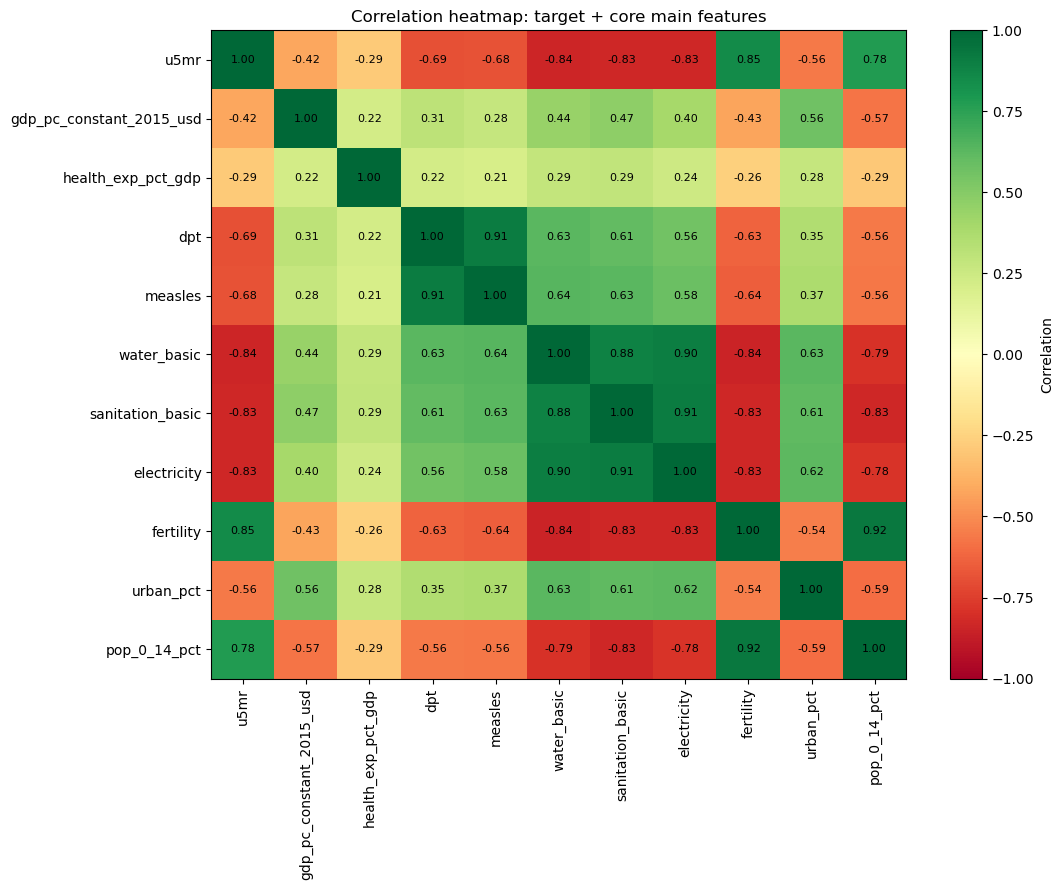

In [50]:
core_plus_target = [
    "u5mr",
    "gdp_pc_constant_2015_usd",
    "health_exp_pct_gdp",
    "dpt",
    "measles",
    "water_basic",
    "sanitation_basic",
    "electricity",
    "fertility",
    "urban_pct",
    "pop_0_14_pct"
]

corr_core = panel_modern[core_plus_target].corr()

plt.figure(figsize=(11, 9))
plt.imshow(corr_core, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_core.columns)), corr_core.columns, rotation=90)
plt.yticks(range(len(corr_core.index)), corr_core.index)

for i in range(len(corr_core.index)):
    for j in range(len(corr_core.columns)):
        plt.text(
            j, i,
            f"{corr_core.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=8
        )

plt.title("Correlation heatmap: target + core main features")
plt.tight_layout()
plt.show()

In [51]:
u5mr_skew_raw = panel_modern["u5mr"].dropna().skew()
u5mr_skew_log = np.log(panel_modern["u5mr"].dropna()).skew()

print("Skewness of raw u5mr:", round(u5mr_skew_raw, 3))
print("Skewness of log(u5mr):", round(u5mr_skew_log, 3))

Skewness of raw u5mr: 2.078
Skewness of log(u5mr): -0.017


In [52]:
u5mr_desc = panel_modern["u5mr"].dropna().describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)
u5mr_desc

count    4704.000000
mean       36.993729
std        41.170921
min         1.400000
1%          2.403000
5%          3.300000
25%         8.400000
50%        20.200000
75%        51.625000
95%       125.355000
99%       173.270000
max       478.900000
Name: u5mr, dtype: float64

In [53]:
q1 = panel_modern["u5mr"].dropna().quantile(0.25)
q3 = panel_modern["u5mr"].dropna().quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print("Potential high-end outlier threshold (IQR rule):", round(upper_bound, 2))
print("Number of values above threshold:", (panel_modern["u5mr"] > upper_bound).sum())

Potential high-end outlier threshold (IQR rule): 116.46
Number of values above threshold: 295


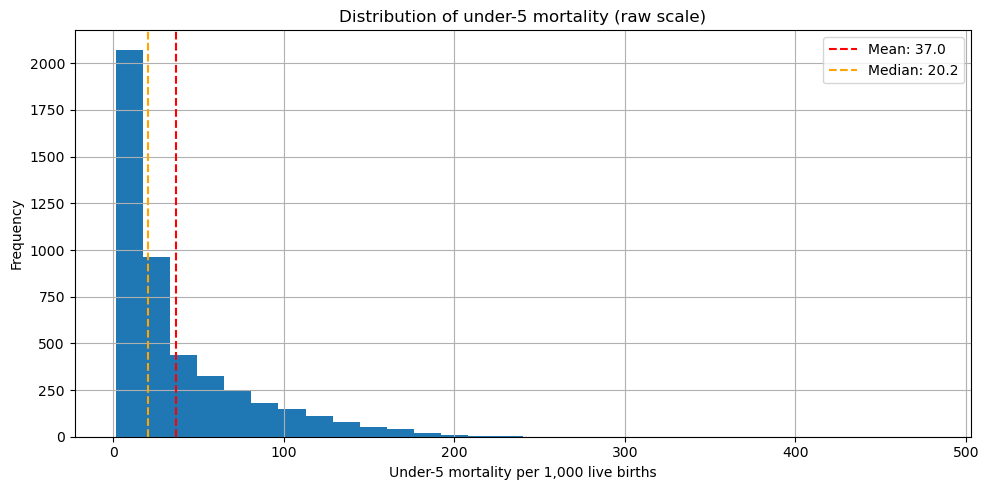

In [54]:
mean_val = panel_modern["u5mr"].dropna().mean()
median_val = panel_modern["u5mr"].dropna().median()

plt.figure(figsize=(10, 5))
plt.hist(panel_modern["u5mr"].dropna(), bins=30)

plt.axvline(mean_val, color="red", linestyle="--", label=f"Mean: {mean_val:.1f}")
plt.axvline(median_val, color="orange", linestyle="--", label=f"Median: {median_val:.1f}")
plt.legend()

plt.title("Distribution of under-5 mortality (raw scale)")
plt.xlabel("Under-5 mortality per 1,000 live births")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

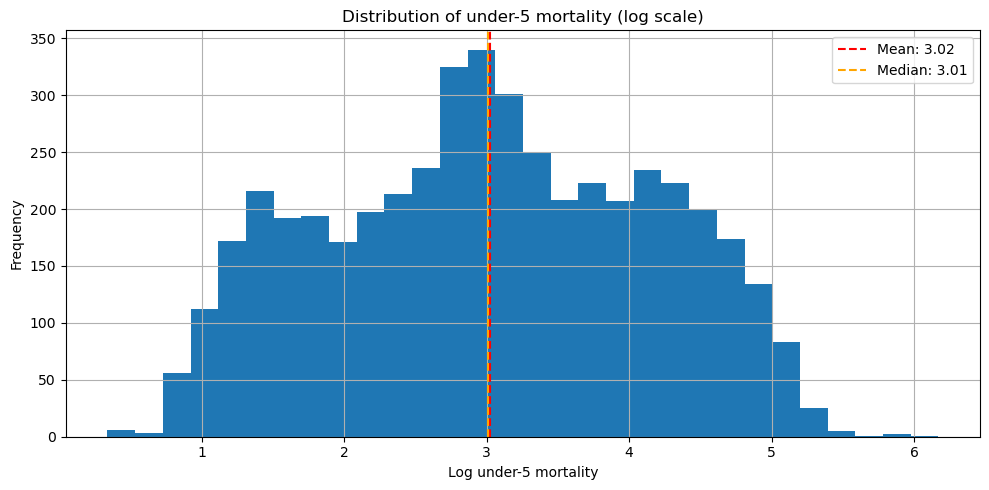

In [55]:
panel_modern["log_u5mr"] = np.log(panel_modern["u5mr"])

mean_log = panel_modern["log_u5mr"].dropna().mean()
median_log = panel_modern["log_u5mr"].dropna().median()

plt.figure(figsize=(10, 5))
plt.hist(panel_modern["log_u5mr"].dropna(), bins=30)

plt.axvline(mean_log, color="red", linestyle="--", label=f"Mean: {mean_log:.2f}")
plt.axvline(median_log, color="orange", linestyle="--", label=f"Median: {median_log:.2f}")
plt.legend()

plt.title("Distribution of under-5 mortality (log scale)")
plt.xlabel("Log under-5 mortality")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

## Target Distribution Conclusion

- The raw under-5 mortality distribution is strongly right-skewed, with a long upper tail and a substantial number of high-end observations.  
- After log transformation, the distribution becomes substantially more symmetric and better suited for regression modeling.  
- This supports the use of **log under-5 mortality** as the main continuous target in the final regression setup.

In [57]:
core_main_features = [
    "gdp_pc_constant_2015_usd",
    "health_exp_pct_gdp",
    "dpt",
    "measles",
    "water_basic",
    "sanitation_basic",
    "electricity",
    "fertility",
    "urban_pct",
    "pop_0_14_pct"
]

extended_features = [
    "gdp_pc_ppp_current",
    "physicians_per_1000",
    "primary_completion",
    "rule_of_law",
    "govt_effectiveness",
    "water_safe",
    "sanitation_safe"
]

eda_only_features = [
    "life_expectancy",
    "neonatal_mortality",
    "population_total",
    "urban_population_total"
]

excluded_from_modeling = [
    "gini",
    "adult_literacy"
]

print("Core main features:", core_main_features)
print("Extended features:", extended_features)
print("EDA only features:", eda_only_features)
print("Excluded from modeling:", excluded_from_modeling)

Core main features: ['gdp_pc_constant_2015_usd', 'health_exp_pct_gdp', 'dpt', 'measles', 'water_basic', 'sanitation_basic', 'electricity', 'fertility', 'urban_pct', 'pop_0_14_pct']
Extended features: ['gdp_pc_ppp_current', 'physicians_per_1000', 'primary_completion', 'rule_of_law', 'govt_effectiveness', 'water_safe', 'sanitation_safe']
EDA only features: ['life_expectancy', 'neonatal_mortality', 'population_total', 'urban_population_total']
Excluded from modeling: ['gini', 'adult_literacy']


## GDP Variable Choice

For the main model, we retain **GDP per capita (constant 2015 US$)** as the preferred income measure because it is inflation-adjusted and easier to interpret over time.

**GDP per capita PPP (current international $)** is retained only as an extended or robustness feature, not as a core main-model predictor.

---

# End of Stage 2 — Data Cleaning, Data Quality Audit, and Early EDA

Stage 2 examined the quality and usability of the prepared country-year candidate panel.

## Completed in Stage 2
- checked duplicate country-year rows
- assessed missingness across variables
- evaluated target availability over time
- evaluated predictor coverage over time
- assessed joint completeness of the target and core predictors by year
- justified the final modeling window using data evidence
- reviewed feature quality and proposed feature groups
- examined correlations among the target and core predictors
- checked the distribution of under-5 mortality on the raw and log scales

## Main conclusions
- the full 1960–2025 horizon is not jointly usable for the main multivariate model
- joint completeness becomes usable from 2000 onward
- 2024 is not available for evaluated backtesting, but it is the real forecast year using 2023 features
- the 2000–2023 period is the most defensible final modeling window
- the raw under-5 mortality distribution is strongly right-skewed
- a log transformation of the target is justified

---

# Stage 3 — Final Modeling Dataset Construction

This stage builds the final one-year-ahead datasets using explicit calendar years.

The design is:

| Feature year | Mortality year predicted |
|---:|---:|
| 2000 | 2001 |
| 2001 | 2002 |
| 2010 | 2011 |
| 2022 | 2023 |
| 2023 | 2024 |

Rows from feature years 2000–2022 have observed mortality outcomes for 2001–2023 and can be used for training/testing. Feature year 2023 is kept separately as the real forecast input for mortality year 2024.

The target is not imputed and no backward filling is used.


## Stage 3 Setup and Aggregate Removal

The modern panel from Stage 2 is copied once. Before constructing the modeling dataset, WDI aggregate entities are removed. These aggregates include region totals, income-group totals, and world-level totals. They are not independent country observations and should not be used as modeling rows.

Region and income-group metadata are not forced into the dataset. They are not baseline predictors, so removing the metadata step makes the notebook simpler and more reproducible.

In [62]:
from pathlib import Path

candidate_project_dirs = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent
]

project_dir = next(
    (
        path for path in candidate_project_dirs
        if (
            (path / "stage1_prepared_data").exists()
            or (path / "stage3_model_data").exists()
            or (path / "WB_WDI_WIDEF (1).csv").exists()
        )
    ),
    Path.cwd()
)

stage3_dir = project_dir / "stage3_model_data"
stage4_dir = project_dir / "stage4_forecast_results"
final_summary_dir = project_dir / "final_summary"

stage3_dir.mkdir(parents=True, exist_ok=True)
stage4_dir.mkdir(parents=True, exist_ok=True)
final_summary_dir.mkdir(parents=True, exist_ok=True)

df_before_aggregate_removal = panel_modern.copy()

aggregate_codes = {
    "AFE", "AFW", "ARB", "CEB", "CSS", "EAP", "EAR", "EAS", "ECA", "ECS",
    "EMU", "EUU", "FCS", "HIC", "HPC", "IBD", "IBT", "IDA", "IDB", "IDX",
    "LAC", "LCN", "LDC", "LIC", "LMC", "LMY", "LTE", "MEA", "MIC", "MNA",
    "NAC", "OED", "OSS", "PRE", "PSS", "PST", "SAS", "SSA", "SSF", "SST",
    "TEA", "TEC", "TLA", "TMN", "TSA", "TSS", "UMC", "WLD"
}

stage3_removed_aggregate_entities = (
    df_before_aggregate_removal.loc[
        df_before_aggregate_removal["country_code"].isin(aggregate_codes),
        ["country_code", "country_name"]
    ]
    .drop_duplicates()
    .sort_values("country_code")
    .reset_index(drop=True)
)

df = df_before_aggregate_removal.loc[
    ~df_before_aggregate_removal["country_code"].isin(aggregate_codes)
].copy()

stage3_aggregate_audit = pd.DataFrame({
    "item": [
        "rows_before_aggregate_removal",
        "rows_after_aggregate_removal",
        "rows_removed",
        "entities_before_aggregate_removal",
        "entities_after_aggregate_removal",
        "entities_removed"
    ],
    "value": [
        len(df_before_aggregate_removal),
        len(df),
        len(df_before_aggregate_removal) - len(df),
        df_before_aggregate_removal["country_code"].nunique(),
        df["country_code"].nunique(),
        df_before_aggregate_removal["country_code"].nunique() - df["country_code"].nunique()
    ]
})

# Consistency audit: if the Stage 1 pycountry ISO3 filter worked correctly,
# zero WDI aggregate entities should survive into panel_modern.
# If this number is > 0, the notebook stops because Stage 1 must be reviewed.
n_aggregates_found = stage3_aggregate_audit.loc[
    stage3_aggregate_audit["item"] == "entities_removed", "value"
].iloc[0]

if int(n_aggregates_found) == 0:
    print(
        "✅ Aggregate check: Stage 1 pycountry filter was complete. "
        "Stage 3 removal is a safety net — no entities removed."
    )
else:
    print(
        f"⚠️  WARNING: {n_aggregates_found} aggregate entities survived "
        "Stage 1 pycountry filter. Stage 2 analysis may have been contaminated. "
        "Review Stage 1 ISO3 filter logic before continuing."
    )
    raise ValueError(
        "Stage 1 filter did not remove all aggregates. "
        f"Found {n_aggregates_found} aggregate entities in panel_modern."
    )

if "log_u5mr" not in df.columns:
    assert (df["u5mr"].dropna() > 0).all()
    df["log_u5mr"] = np.log(df["u5mr"])

required_start_cols = ["country_code", "country_name", "year", "u5mr", "log_u5mr"] + core_main_features
missing_start_cols = [col for col in required_start_cols if col not in df.columns]
assert len(missing_start_cols) == 0, missing_start_cols

stage3_duplicate_rows = df.duplicated(subset=["country_code", "year"]).sum()
assert stage3_duplicate_rows == 0

print("Project directory:", project_dir)
print("Stage 3 shape after aggregate removal:", df.shape)
print("Entities after aggregate removal:", df["country_code"].nunique())
print("Year range:", int(df["year"].min()), "to", int(df["year"].max()))
display(stage3_aggregate_audit)
display(stage3_removed_aggregate_entities.head(20))
display(df[["country_code", "country_name", "year", "u5mr"] + core_main_features].head())

✅ Aggregate check: Stage 1 pycountry filter was complete. Stage 3 removal is a safety net — no entities removed.
Project directory: C:\Users\ayoub\test\corona test ML
Stage 3 shape after aggregate removal: (5184, 28)
Entities after aggregate removal: 216
Year range: 2000 to 2023


,item,value
0,rows_before_aggregate_removal,5184
1,rows_after_aggregate_removal,5184
2,rows_removed,0
3,entities_before_aggregate_removal,216
4,entities_after_aggregate_removal,216
5,entities_removed,0


,country_code,country_name


,country_code,country_name,year,u5mr,gdp_pc_constant_2015_usd,health_exp_pct_gdp,dpt,measles,water_basic,sanitation_basic,electricity,fertility,urban_pct,pop_0_14_pct
40,ABW,Aruba,2000,NaN,28104.895436,NaN,NaN,NaN,95.233536,97.973104,91.7,1.845,65.354550,23.447103
41,ABW,Aruba,2001,NaN,29007.738696,NaN,NaN,NaN,95.359056,98.012508,100.0,1.813,65.335114,23.165938
42,ABW,Aruba,2002,NaN,28535.463948,NaN,NaN,NaN,95.484576,98.051913,100.0,1.800,65.282069,22.824844
43,ABW,Aruba,2003,NaN,28525.807706,NaN,NaN,NaN,95.610096,98.091317,100.0,1.808,65.198292,22.456939
44,ABW,Aruba,2004,NaN,29959.774819,NaN,NaN,NaN,95.735616,98.130722,100.0,1.819,65.088653,22.076438


## Metadata Policy

Region and income-group variables are not used as baseline predictors. Since the raw WDI file already contains aggregate entities, the correct step is to remove those aggregate observations rather than reintroduce region or income metadata as if they were modeling rows.

The final baseline dataset therefore keeps only country/entity-year observations and numeric predictor variables.

In [64]:
metadata_policy = pd.DataFrame({
    "item": [
        "aggregate WDI observations",
        "region metadata",
        "income-group metadata",
        "baseline model predictors"
    ],
    "decision": [
        "removed before modeling",
        "not required for the baseline model",
        "not required for the baseline model",
        "numeric core predictors only"
    ],
    "reason": [
        "aggregates are not independent country/entity observations",
        "metadata is useful for interpretation but not needed here",
        "metadata is useful for interpretation but not needed here",
        "keeps Stage 4 simple and avoids artificial metadata problems"
    ]
})

display(metadata_policy)

,item,decision,reason
0,aggregate WDI observations,removed before modeling,aggregates are not independent country/entity ...
1,region metadata,not required for the baseline model,metadata is useful for interpretation but not ...
2,income-group metadata,not required for the baseline model,metadata is useful for interpretation but not ...
3,baseline model predictors,numeric core predictors only,keeps Stage 4 simple and avoids artificial met...


## GDP Transformation

GDP per capita is right-skewed. The baseline uses `log_gdp_pc` instead of raw GDP per capita. The raw GDP column is still saved for transparency.

In [66]:
gdp_col = "gdp_pc_constant_2015_usd"
assert (df[gdp_col].dropna() > 0).all()

df["log_gdp_pc"] = np.log(df[gdp_col])

core_model_features = [
    "log_gdp_pc",
    "health_exp_pct_gdp",
    "dpt",
    "measles",
    "water_basic",
    "sanitation_basic",
    "electricity",
    "fertility",
    "urban_pct",
    "pop_0_14_pct"
]

feature_role_stage3 = pd.DataFrame({
    "feature": core_model_features + extended_features,
    "role": ["baseline predictor"] * len(core_model_features) + ["saved, not baseline"] * len(extended_features)
})

print("Raw GDP skewness:", round(df[gdp_col].dropna().skew(), 3))
print("Log GDP skewness:", round(df["log_gdp_pc"].dropna().skew(), 3))
display(feature_role_stage3)

Raw GDP skewness: 2.869
Log GDP skewness: 0.016


,feature,role
0,log_gdp_pc,baseline predictor
1,health_exp_pct_gdp,baseline predictor
2,dpt,baseline predictor
3,measles,baseline predictor
4,water_basic,baseline predictor
5,sanitation_basic,baseline predictor
6,electricity,baseline predictor
7,fertility,baseline predictor
8,urban_pct,baseline predictor
9,pop_0_14_pct,baseline predictor


## Preston-Style Check

This is a visual audit, not a model. It checks whether higher income is generally associated with lower under-5 mortality. The plot is not colored by region because region metadata is not used in the final baseline dataset.

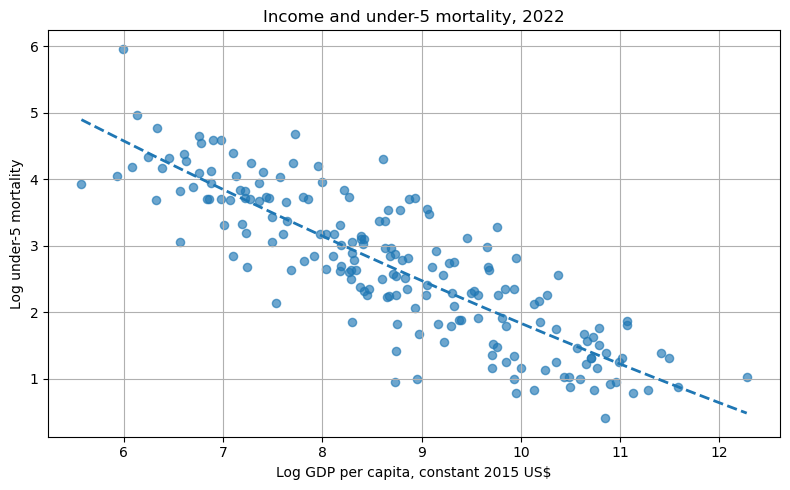

In [68]:
preston_year = 2022
preston_df = df[(df["year"] == preston_year) & df["log_gdp_pc"].notna() & df["log_u5mr"].notna()].copy()

plt.figure(figsize=(8, 5))
plt.scatter(preston_df["log_gdp_pc"], preston_df["log_u5mr"], alpha=0.65, s=35)

if preston_df.shape[0] >= 3:
    x = preston_df["log_gdp_pc"].to_numpy()
    y = preston_df["log_u5mr"].to_numpy()
    curve = np.poly1d(np.polyfit(x, y, deg=2))
    x_grid = np.linspace(x.min(), x.max(), 100)
    plt.plot(x_grid, curve(x_grid), linestyle="--", linewidth=2)

plt.title("Income and under-5 mortality, 2022")
plt.xlabel("Log GDP per capita, constant 2015 US$")
plt.ylabel("Log under-5 mortality")
plt.grid(True)
plt.tight_layout()
plt.show()

## One-Year-Ahead Target with Explicit Calendar Years

For each country, the mortality outcome is taken from the following calendar year. A row is kept as a supervised training/testing row only when the next observed row is exactly one calendar year later.


In [70]:
df = df.sort_values(["country_code", "year"]).copy()

# Explicit calendar-year outcome: feature year -> mortality year predicted
df["mortality_year_predicted"] = df.groupby("country_code")["year"].shift(-1)
df["u5mr_mortality_year"] = df.groupby("country_code")["u5mr"].shift(-1)

gap_mask = df["mortality_year_predicted"] != df["year"] + 1
df.loc[gap_mask, "u5mr_mortality_year"] = np.nan

assert (df["u5mr_mortality_year"].dropna() > 0).all()
df["log_u5mr_mortality_year"] = np.log(df["u5mr_mortality_year"])

print("Rows with observed mortality-year target:", df["u5mr_mortality_year"].notna().sum())
display(df[[
    "country_code", "country_name", "year", "mortality_year_predicted",
    "u5mr", "u5mr_mortality_year", "log_u5mr_mortality_year"
]].head(12))


Rows with observed mortality-year target: 4508


,country_code,country_name,year,mortality_year_predicted,u5mr,u5mr_mortality_year,log_u5mr_mortality_year
40,ABW,Aruba,2000,2001.0,NaN,NaN,NaN
41,ABW,Aruba,2001,2002.0,NaN,NaN,NaN
42,ABW,Aruba,2002,2003.0,NaN,NaN,NaN
43,ABW,Aruba,2003,2004.0,NaN,NaN,NaN
44,ABW,Aruba,2004,2005.0,NaN,NaN,NaN
45,ABW,Aruba,2005,2006.0,NaN,NaN,NaN
46,ABW,Aruba,2006,2007.0,NaN,NaN,NaN
47,ABW,Aruba,2007,2008.0,NaN,NaN,NaN
48,ABW,Aruba,2008,2009.0,NaN,NaN,NaN
49,ABW,Aruba,2009,2010.0,NaN,NaN,NaN


## Calendar-Year Shift Verification

This required audit verifies that the mortality-year outcome matches a direct lookup of under-5 mortality in the following calendar year for the same country.


In [72]:
lookup = df[["country_code", "year", "u5mr"]].rename(columns={"year": "lookup_mortality_year", "u5mr": "u5mr_direct_lookup"})

calendar_year_check = df[["country_code", "country_name", "year", "mortality_year_predicted", "u5mr_mortality_year"]].merge(
    lookup,
    left_on=["country_code", "mortality_year_predicted"],
    right_on=["country_code", "lookup_mortality_year"],
    how="left"
)

calendar_year_check = calendar_year_check[
    calendar_year_check["mortality_year_predicted"].eq(calendar_year_check["year"] + 1)
    & calendar_year_check["u5mr_mortality_year"].notna()
].copy()
max_calendar_year_abs_diff = (calendar_year_check["u5mr_mortality_year"] - calendar_year_check["u5mr_direct_lookup"]).abs().max()

print("Calendar-year verification rows:", calendar_year_check.shape[0])
print("Maximum absolute difference:", max_calendar_year_abs_diff)
assert np.isclose(max_calendar_year_abs_diff, 0.0)

display(calendar_year_check[[
    "country_code", "country_name", "year", "mortality_year_predicted",
    "u5mr_mortality_year", "u5mr_direct_lookup"
]].head(10))


Calendar-year verification rows: 4508
Maximum absolute difference: 0.0


,country_code,country_name,year,mortality_year_predicted,u5mr_mortality_year,u5mr_direct_lookup
24,AFG,Afghanistan,2000,2001.0,127.4,127.4
25,AFG,Afghanistan,2001,2002.0,123.1,123.1
26,AFG,Afghanistan,2002,2003.0,118.7,118.7
27,AFG,Afghanistan,2003,2004.0,114.2,114.2
28,AFG,Afghanistan,2004,2005.0,109.7,109.7
29,AFG,Afghanistan,2005,2006.0,105.1,105.1
30,AFG,Afghanistan,2006,2007.0,100.7,100.7
31,AFG,Afghanistan,2007,2008.0,96.3,96.3
32,AFG,Afghanistan,2008,2009.0,92.2,92.2
33,AFG,Afghanistan,2009,2010.0,88.3,88.3


## Supervised Historical Rows and Real 2024 Forecast Rows

Feature years 2000–2022 have observed mortality outcomes for 2001–2023, so they form the supervised modeling dataset.

Feature year 2023 is **not** used as a supervised training row because observed 2024 mortality is not available in the WDI data. Instead, 2023 is kept as the real forecast input for predicting 2024 mortality and 2024 high-risk status.


In [74]:
df_model_window = df[(df["year"] >= 2000) & (df["year"] <= 2022)].copy()
forecast_2024_input = df[df["year"] == 2023].copy()

print("Rows in supervised modeling window:", df_model_window.shape[0])
print("Entities in supervised modeling window:", df_model_window["country_code"].nunique())
print("Supervised feature-year range:", int(df_model_window["year"].min()), "to", int(df_model_window["year"].max()))
print("Rows available for real 2024 forecast using 2023 features:", forecast_2024_input.shape[0])
print("Forecast feature year:", int(forecast_2024_input["year"].min()) if len(forecast_2024_input) else "missing")


Rows in supervised modeling window: 4968
Entities in supervised modeling window: 216
Supervised feature-year range: 2000 to 2022
Rows available for real 2024 forecast using 2023 features: 216
Forecast feature year: 2023


## Stage 3 Modeling Dataset with Training-Pipeline Imputation Policy

The final supervised modeling dataset does **not** impute the mortality target and does **not** backward fill any variable. Predictor missingness is no longer handled by globally dropping all incomplete feature rows, because that can bias a WDI panel toward better-measured countries.

The corrected design is:

- keep rows from feature years 2000–2022 only when the mortality outcome for 2001–2023 is observed;
- keep feature year 2023 separately for the real 2024 forecast;
- keep missing predictor values in the saved modeling dataset;
- impute predictors later inside sklearn pipelines using training-period statistics only;
- keep a complete-case audit only as a diagnostic, not as the main modeling rule.


In [76]:
id_cols = ["country_code", "country_name", "year", "mortality_year_predicted"]
raw_reference_cols = ["gdp_pc_constant_2015_usd"]
target_cols = ["u5mr", "log_u5mr", "u5mr_mortality_year", "log_u5mr_mortality_year"]

model_base_cols = list(dict.fromkeys(id_cols + raw_reference_cols + core_model_features + extended_features + target_cols))
required_target_cols = ["u5mr_mortality_year", "log_u5mr_mortality_year"]

stage3_model_base_dataset = (
    df_model_window[model_base_cols]
    .dropna(subset=required_target_cols)
    .copy()
    .reset_index(drop=True)
)

forecast_2024_cols = list(dict.fromkeys(["country_code", "country_name", "year"] + raw_reference_cols + core_model_features + extended_features + ["u5mr", "log_u5mr"]))
stage3_forecast_2024_input = (
    forecast_2024_input[forecast_2024_cols]
    .copy()
    .reset_index(drop=True)
)
stage3_forecast_2024_input["mortality_year_predicted"] = 2024

complete_case_required_cols = core_model_features + required_target_cols
complete_case_dataset = (
    df_model_window[model_base_cols]
    .dropna(subset=complete_case_required_cols)
    .copy()
    .reset_index(drop=True)
)

missing_predictor_counts = (
    stage3_model_base_dataset[core_model_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_data_audit = pd.DataFrame({
    "item": [
        "supervised_feature_window_rows_2000_2022",
        "rows_with_observed_mortality_outcome_2001_2023",
        "rows_complete_on_all_core_predictors_and_target",
        "extra_rows_retained_by_pipeline_imputation_design",
        "real_forecast_input_feature_year_2023_rows",
        "real_forecast_mortality_year",
        "target_imputation",
        "predictor_imputation"
    ],
    "value": [
        df_model_window.shape[0],
        stage3_model_base_dataset.shape[0],
        complete_case_dataset.shape[0],
        stage3_model_base_dataset.shape[0] - complete_case_dataset.shape[0],
        stage3_forecast_2024_input.shape[0],
        2024,
        "not used",
        "performed inside Stage 4 pipelines using training data only"
    ]
})

print("Supervised model base dataset shape:", stage3_model_base_dataset.shape)
print("2024 forecast input shape:", stage3_forecast_2024_input.shape)
print("Complete-case rows retained only for audit:", complete_case_dataset.shape[0])
display(missing_predictor_counts.to_frame("missing_predictor_values"))
display(missing_data_audit)


Supervised model base dataset shape: (4508, 26)
2024 forecast input shape: (216, 24)
Complete-case rows retained only for audit: 4190


,missing_predictor_values
health_exp_pct_gdp,170
sanitation_basic,152
water_basic,143
log_gdp_pc,104
dpt,88
measles,88
electricity,48
fertility,0
urban_pct,0
pop_0_14_pct,0


,item,value
0,supervised_feature_window_rows_2000_2022,4968
1,rows_with_observed_mortality_outcome_2001_2023,4508
2,rows_complete_on_all_core_predictors_and_target,4190
3,extra_rows_retained_by_pipeline_imputation_design,318
4,real_forecast_input_feature_year_2023_rows,216
5,real_forecast_mortality_year,2024
6,target_imputation,not used
7,predictor_imputation,performed inside Stage 4 pipelines using train...


## Classification Base Dataset

The binary high-risk label is still **not** finalized in Stage 3. The 75th percentile threshold is calculated only from the training period inside Stage 4, then applied unchanged to the chronological test period. This prevents the test-period target distribution from defining the labels.

In [78]:
stage3_regression_dataset = stage3_model_base_dataset.copy()
stage3_classification_base_dataset = stage3_model_base_dataset.copy()

# COVID-period indicator for methodological transparency.
# The disrupted mortality years are 2020 and 2021; these correspond to
# feature years 2019 and 2020 in the one-year-ahead setup.
covid_mortality_years = {2020, 2021}
stage3_regression_dataset["covid_affected_target_year"] = (
    stage3_regression_dataset["mortality_year_predicted"]
    .isin(covid_mortality_years)
    .astype(int)
)
stage3_classification_base_dataset["covid_affected_target_year"] = (
    stage3_classification_base_dataset["mortality_year_predicted"]
    .isin(covid_mortality_years)
    .astype(int)
)

covid_rows = int(stage3_regression_dataset["covid_affected_target_year"].sum())
print(f"Rows with COVID-affected target year: {covid_rows}")
print(f"  ({covid_rows / len(stage3_regression_dataset):.1%} of supervised dataset)")

print("Regression modeling base shape:", stage3_regression_dataset.shape)
print("Classification modeling base shape:", stage3_classification_base_dataset.shape)
print("2024 forecast input shape:", stage3_forecast_2024_input.shape)
print("Missing predictor values are intentionally retained for pipeline imputation.")


Rows with COVID-affected target year: 392
  (8.7% of supervised dataset)
Regression modeling base shape: (4508, 27)
Classification modeling base shape: (4508, 27)
2024 forecast input shape: (216, 24)
Missing predictor values are intentionally retained for pipeline imputation.


## Stage 3 Sanity Checks

These checks verify target availability, target calendar-year pairing correctness, duplicated country-years, and the absence of impossible target values. Predictor missingness is allowed at this stage because it is handled inside Stage 4 pipelines.

In [80]:
assert stage3_regression_dataset.duplicated(subset=["country_code", "year"]).sum() == 0
assert stage3_classification_base_dataset.duplicated(subset=["country_code", "year"]).sum() == 0
assert stage3_regression_dataset[required_target_cols].isna().sum().sum() == 0
assert stage3_regression_dataset["year"].between(2000, 2022).all()
assert stage3_regression_dataset["mortality_year_predicted"].between(2001, 2023).all()
assert (stage3_regression_dataset["u5mr_mortality_year"] > 0).all()
assert np.isclose(max_calendar_year_abs_diff, 0.0)
assert (stage3_forecast_2024_input["year"] == 2023).all()
assert (stage3_forecast_2024_input["mortality_year_predicted"] == 2024).all()

stage3_sanity_summary = pd.DataFrame({
    "check": [
        "duplicate country-year rows",
        "observed mortality outcome for supervised rows",
        "supervised feature-year range",
        "supervised mortality-year range",
        "positive mortality-year target",
        "verified calendar-year shift",
        "2023 feature rows kept for real 2024 forecast",
        "classification label delayed to Stage 4",
        "predictor missingness retained for pipeline imputation"
    ],
    "result": [
        "passed",
        "passed",
        f"{stage3_regression_dataset['year'].min()}-{stage3_regression_dataset['year'].max()}",
        f"{int(stage3_regression_dataset['mortality_year_predicted'].min())}-{int(stage3_regression_dataset['mortality_year_predicted'].max())}",
        "passed",
        "passed",
        "passed",
        "passed",
        "passed"
    ]
})

display(stage3_sanity_summary)


,check,result
0,duplicate country-year rows,passed
1,observed mortality outcome for supervised rows,passed
2,supervised feature-year range,2000-2022
3,supervised mortality-year range,2001-2023
4,positive mortality-year target,passed
5,verified calendar-year shift,passed
6,2023 feature rows kept for real 2024 forecast,passed
7,classification label delayed to Stage 4,passed
8,predictor missingness retained for pipeline im...,passed


## Save Stage 3 Outputs

The saved Stage 3 datasets contain all rows with observed mortality-year targets. Missing predictor values are intentionally preserved so that Stage 4 can impute predictors within sklearn pipelines using training-period information only.

In [82]:
stage3_regression_dataset.to_csv(stage3_dir / "regression_dataset.csv", index=False)
stage3_classification_base_dataset.to_csv(stage3_dir / "classification_base_dataset.csv", index=False)
stage3_forecast_2024_input.to_csv(stage3_dir / "forecast_2024_input_feature_year_2023.csv", index=False)
stage3_aggregate_audit.to_csv(stage3_dir / "aggregate_removal_audit.csv", index=False)
stage3_removed_aggregate_entities.to_csv(stage3_dir / "removed_aggregate_entities.csv", index=False)
missing_data_audit.to_csv(stage3_dir / "missing_data_strategy_audit.csv", index=False)
missing_predictor_counts.to_frame("missing_predictor_values").to_csv(stage3_dir / "missing_predictor_values_before_imputation.csv")

print("Saved:", stage3_dir / "regression_dataset.csv", stage3_regression_dataset.shape)
print("Saved:", stage3_dir / "classification_base_dataset.csv", stage3_classification_base_dataset.shape)
print("Saved:", stage3_dir / "forecast_2024_input_feature_year_2023.csv", stage3_forecast_2024_input.shape)
print("Saved Stage 3 audits in:", stage3_dir)


Saved: C:\Users\ayoub\test\corona test ML\stage3_model_data\regression_dataset.csv (4508, 27)
Saved: C:\Users\ayoub\test\corona test ML\stage3_model_data\classification_base_dataset.csv (4508, 27)
Saved: C:\Users\ayoub\test\corona test ML\stage3_model_data\forecast_2024_input_feature_year_2023.csv (216, 24)
Saved Stage 3 audits in: C:\Users\ayoub\test\corona test ML\stage3_model_data


---

# End of Stage 3 — Final Modeling Dataset Construction

The corrected Stage 3 output is a supervised historical modeling base dataset plus a separate real 2024 forecast input file. The supervised rows use feature years 2000–2022 and mortality outcomes 2001–2023. Feature year 2023 is reserved for the real forecast of 2024 mortality and high-risk status.

The mortality target is not imputed, aggregate WDI entities are excluded, and missing predictors are retained so that Stage 4 can apply training-only imputation inside sklearn pipelines.


# Stage 4 — Forecast Modeling with Temporal Validation and Pipeline Imputation

This final Stage 4 version evaluates models through a historical backtest and then produces the real 2024 forecast.

The key corrections are:

- predictor imputation is performed inside sklearn pipelines;
- the historical evaluation is chronological: train on feature years 2000–2015 and test on feature years 2016–2022;
- the test/backtest predictions correspond to mortality years 2017–2023, which are already observed;
- after selecting the model, it is refit on all observed historical pairs: feature years 2000–2022 and mortality years 2001–2023;
- the real forecast uses 2023 predictor values to estimate 2024 under-5 mortality and high-risk status;
- classification thresholds are computed from training/historical target values only;
- a persistence baseline is added: predict the mortality year with the feature-year mortality value.


## Stage 4 Setup

In [86]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import Ridge, ElasticNet, LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import ParameterGrid

stage4_dir = project_dir / "stage4_forecast_results"
final_report_dir = project_dir / "final_results_for_report"
figures_dir = final_report_dir / "figures"
metrics_dir = final_report_dir / "metrics"
predictions_dir = final_report_dir / "predictions"
importance_dir = final_report_dir / "feature_importance"
diagnostics_dir = final_report_dir / "diagnostics"
summary_dir = final_report_dir / "summary"

for folder in [stage4_dir, final_report_dir, figures_dir, metrics_dir, predictions_dir, importance_dir, diagnostics_dir, summary_dir]:
    folder.mkdir(parents=True, exist_ok=True)

if "stage3_regression_dataset" not in globals():
    stage3_regression_dataset = pd.read_csv(stage3_dir / "regression_dataset.csv")
if "stage3_classification_base_dataset" not in globals():
    stage3_classification_base_dataset = pd.read_csv(stage3_dir / "classification_base_dataset.csv")
if "stage3_forecast_2024_input" not in globals():
    stage3_forecast_2024_input = pd.read_csv(stage3_dir / "forecast_2024_input_feature_year_2023.csv")

stage4_features = core_model_features.copy()
for forbidden in ["u5mr", "log_u5mr", "u5mr_mortality_year", "log_u5mr_mortality_year"]:
    assert forbidden not in stage4_features

modeling_df = stage3_regression_dataset.copy()
classification_base_df = stage3_classification_base_dataset.copy()

print("Stage 4 dataset shape:", modeling_df.shape)
print("Predictors:", stage4_features)

Stage 4 dataset shape: (4508, 27)
Predictors: ['log_gdp_pc', 'health_exp_pct_gdp', 'dpt', 'measles', 'water_basic', 'sanitation_basic', 'electricity', 'fertility', 'urban_pct', 'pop_0_14_pct']


## Imputation Bias Audit

The sklearn pipelines use median imputation fitted only on the training data, so preprocessing does not leak information from the test period. However, a single global median can still be imperfect for data-sparse countries because it mixes countries at very different development levels. This is treated as a limitation and documented in the diagnostics folder.

In [88]:
# Methodological audit for global median imputation.
# This does not change the model; it documents a known limitation transparently.
missing_by_feature = (
    modeling_df[stage4_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

most_affected_features = missing_by_feature[missing_by_feature > 0].head(5).index.tolist()
if len(most_affected_features) == 0:
    most_affected_features_text = "none among final baseline predictors"
else:
    most_affected_features_text = ", ".join(most_affected_features)

imputation_bias_audit = pd.DataFrame({
    "item": [
        "imputation_strategy",
        "known_bias",
        "most_affected_final_predictors",
        "mitigation_used_in_this_notebook",
        "stronger_future_mitigation",
        "effect_on_results"
    ],
    "value": [
        "SimpleImputer(strategy='median') inside sklearn pipelines, fitted only on training data",
        "A global median can mix high-income and low-income countries. Data-sparse countries may receive values that are not locally realistic.",
        most_affected_features_text,
        "Leakage is avoided because the imputer is fitted only on the training split or final historical refit data.",
        "A country-aware or income-group-aware imputer could reduce cross-country imputation bias in a larger extension.",
        "Predictions for data-sparse countries and feature importance for heavily imputed features should be interpreted cautiously."
    ]
})

imputation_bias_audit.to_csv(diagnostics_dir / "imputation_bias_audit.csv", index=False)
display(imputation_bias_audit)
display(missing_by_feature.to_frame("missing_values_in_modeling_dataset"))

,item,value
0,imputation_strategy,SimpleImputer(strategy='median') inside sklear...
1,known_bias,A global median can mix high-income and low-in...
2,most_affected_final_predictors,"health_exp_pct_gdp, sanitation_basic, water_ba..."
3,mitigation_used_in_this_notebook,Leakage is avoided because the imputer is fitt...
4,stronger_future_mitigation,A country-aware or income-group-aware imputer ...
5,effect_on_results,Predictions for data-sparse countries and feat...


,missing_values_in_modeling_dataset
health_exp_pct_gdp,170
sanitation_basic,152
water_basic,143
log_gdp_pc,104
dpt,88
measles,88
electricity,48
fertility,0
urban_pct,0
pop_0_14_pct,0


## Primary Chronological Backtest Split

The project is a one-year-ahead prediction task. The primary evaluation is therefore temporal: the model learns from earlier feature years and is evaluated on later feature years.

This is a backtest, not the real forecast:

| Step | Feature years used | Mortality years predicted | Purpose |
|---|---:|---:|---|
| Train split | 2000–2015 | 2001–2016 | fit candidate models |
| Test split | 2016–2022 | 2017–2023 | compare candidate models |
| Final refit | 2000–2022 | 2001–2023 | train selected model on all observed historical pairs |
| Real forecast | 2023 only | 2024 | forecast/classify 2024 |


In [90]:
chrono_train_df = modeling_df[(modeling_df["year"] >= 2000) & (modeling_df["year"] <= 2015)].copy()
chrono_test_df = modeling_df[(modeling_df["year"] >= 2016) & (modeling_df["year"] <= 2022)].copy()

assert chrono_train_df["year"].min() == 2000
assert chrono_train_df["year"].max() == 2015
assert chrono_test_df["year"].min() == 2016
assert chrono_test_df["year"].max() == 2022
assert chrono_train_df["year"].max() < chrono_test_df["year"].min()
assert chrono_train_df["log_u5mr_mortality_year"].notna().all()
assert chrono_test_df["log_u5mr_mortality_year"].notna().all()

chronological_split_summary = pd.DataFrame({
    "split": ["train", "test/backtest"],
    "feature_year_start": [int(chrono_train_df["year"].min()), int(chrono_test_df["year"].min())],
    "feature_year_end": [int(chrono_train_df["year"].max()), int(chrono_test_df["year"].max())],
    "mortality_year_start": [int(chrono_train_df["mortality_year_predicted"].min()), int(chrono_test_df["mortality_year_predicted"].min())],
    "mortality_year_end": [int(chrono_train_df["mortality_year_predicted"].max()), int(chrono_test_df["mortality_year_predicted"].max())],
    "rows": [len(chrono_train_df), len(chrono_test_df)],
    "entities": [chrono_train_df["country_code"].nunique(), chrono_test_df["country_code"].nunique()]
})

chronological_split_summary.to_csv(metrics_dir / "chronological_split_summary.csv", index=False)
display(chronological_split_summary)


,split,feature_year_start,feature_year_end,mortality_year_start,mortality_year_end,rows,entities
0,train,2000,2015,2001,2016,3136,196
1,test/backtest,2016,2022,2017,2023,1372,196


## Chronological Validation Folds

Hyperparameters are tuned with expanding-window validation inside the training period. This is more appropriate than random or grouped folds for a forecasting problem.

In [92]:
temporal_cv_folds = [
    {"fold": 1, "train_start": 2000, "train_end": 2007, "validation_start": 2008, "validation_end": 2009},
    {"fold": 2, "train_start": 2000, "train_end": 2009, "validation_start": 2010, "validation_end": 2011},
    {"fold": 3, "train_start": 2000, "train_end": 2011, "validation_start": 2012, "validation_end": 2013},
    {"fold": 4, "train_start": 2000, "train_end": 2013, "validation_start": 2014, "validation_end": 2015}
]

temporal_cv_table = pd.DataFrame(temporal_cv_folds)
temporal_cv_table.to_csv(metrics_dir / "temporal_cv_folds.csv", index=False)
display(temporal_cv_table)


,fold,train_start,train_end,validation_start,validation_end
0,1,2000,2007,2008,2009
1,2,2000,2009,2010,2011
2,3,2000,2011,2012,2013
3,4,2000,2013,2014,2015


## Evaluation Functions

In [94]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    if y_score is None or len(np.unique(np.asarray(y_score))) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))


def regression_metric_row(y_true_log, y_pred_log):
    actual_original = np.exp(y_true_log)
    pred_original = np.exp(y_pred_log)
    return {
        "rmse_log": rmse(y_true_log, y_pred_log),
        "mae_log": float(mean_absolute_error(y_true_log, y_pred_log)),
        "r2_log": float(r2_score(y_true_log, y_pred_log)),
        "mae_original_u5mr": float(mean_absolute_error(actual_original, pred_original))
    }


def classification_metric_row(y_true, y_pred, y_score):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_roc_auc(y_true, y_score)
    }


def get_classifier_scores(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.shape[1] > 1:
            return proba[:, 1]
        return np.zeros(X.shape[0])
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)

## Model Catalogues

All ML models use an imputer inside the pipeline. Scaling is used only where it is appropriate. Tree ensembles use at least 200 estimators.

In [96]:
regression_catalogue = {
    "Dummy mean": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DummyRegressor(strategy="mean"))]),
        "params": {}
    },
    "Ridge Regression": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", Ridge())]),
        "params": {"model__alpha": [0.1, 1.0, 10.0, 50.0]}
    },
    "Elastic Net Regression": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", ElasticNet(max_iter=10000, random_state=42))]),
        "params": {"model__alpha": [0.001, 0.01, 0.1], "model__l1_ratio": [0.2, 0.5, 0.8]}
    },
    "K-nearest Neighbors Regression": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", KNeighborsRegressor())]),
        "params": {"model__n_neighbors": [3, 5, 9, 15], "model__weights": ["uniform", "distance"]}
    },
    "Random Forest Regression": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))]),
        "params": {"model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 3, 5]}
    },
    "Extra Trees Regression": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1))]),
        "params": {"model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 3, 5]}
    },
    "Gradient Boosting Regression": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", GradientBoostingRegressor(n_estimators=200, random_state=42))]),
        "params": {"model__learning_rate": [0.03, 0.05, 0.1], "model__max_depth": [2, 3]}
    }
}

classification_catalogue = {
    "Dummy majority": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DummyClassifier(strategy="most_frequent"))]),
        "params": {}
    },
    "Logistic Regression": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=3000, random_state=42))]),
        "params": {"model__C": [0.1, 1.0, 10.0], "model__class_weight": [None, "balanced"]}
    },
    "Gaussian Naive Bayes": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", GaussianNB())]),
        "params": {"model__var_smoothing": [1e-9, 1e-8, 1e-7]}
    },
    "K-nearest Neighbors Classifier": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
        "params": {"model__n_neighbors": [3, 5, 9, 15], "model__weights": ["uniform", "distance"]}
    },
    "Random Forest Classifier": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),
        "params": {"model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 3, 5], "model__class_weight": [None, "balanced"]}
    },
    "Extra Trees Classifier": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),
        "params": {"model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 3, 5], "model__class_weight": [None, "balanced"]}
    },
    "Gradient Boosting Classifier": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", GradientBoostingClassifier(n_estimators=200, random_state=42))]),
        "params": {"model__learning_rate": [0.03, 0.05, 0.1], "model__max_depth": [2, 3]}
    }
}

## Regression: Persistence Baseline

The persistence baseline predicts mortality year’s under-5 mortality with the current year’s under-5 mortality. This is the essential benchmark for a slowly changing outcome.

In [98]:
def evaluate_persistence_regression(train_df, test_df, folds):
    fold_rows = []
    for fold in folds:
        fold_train = train_df[(train_df["year"] >= fold["train_start"]) & (train_df["year"] <= fold["train_end"])]
        fold_val = train_df[(train_df["year"] >= fold["validation_start"]) & (train_df["year"] <= fold["validation_end"])]
        train_metrics = regression_metric_row(fold_train["log_u5mr_mortality_year"], np.log(fold_train["u5mr"]))
        val_metrics = regression_metric_row(fold_val["log_u5mr_mortality_year"], np.log(fold_val["u5mr"]))
        fold_rows.append({"model": "Persistence baseline", "fold": fold["fold"], "train_rmse_log": train_metrics["rmse_log"], "validation_rmse_log": val_metrics["rmse_log"]})
    fold_df = pd.DataFrame(fold_rows)
    train_full = regression_metric_row(train_df["log_u5mr_mortality_year"], np.log(train_df["u5mr"]))
    test_full = regression_metric_row(test_df["log_u5mr_mortality_year"], np.log(test_df["u5mr"]))
    result = {
        "model": "Persistence baseline",
        "best_params": "not applicable",
        "cv_train_rmse_log": fold_df["train_rmse_log"].mean(),
        "cv_rmse_log": fold_df["validation_rmse_log"].mean(),
        "train_rmse_log": train_full["rmse_log"],
        "test_rmse_log": test_full["rmse_log"],
        "test_mae_log": test_full["mae_log"],
        "test_r2_log": test_full["r2_log"],
        "test_mae_original_u5mr": test_full["mae_original_u5mr"],
        "test_minus_train_rmse_log": test_full["rmse_log"] - train_full["rmse_log"],
        "test_minus_cv_rmse_log": test_full["rmse_log"] - fold_df["validation_rmse_log"].mean()
    }
    predictions = test_df[["country_code", "country_name", "year", "mortality_year_predicted", "u5mr", "u5mr_mortality_year", "log_u5mr_mortality_year"]].copy()
    predictions["actual_log_u5mr_mortality_year"] = predictions["log_u5mr_mortality_year"]
    predictions["predicted_log_u5mr_mortality_year"] = np.log(predictions["u5mr"])
    predictions["actual_u5mr_mortality_year"] = np.exp(predictions["actual_log_u5mr_mortality_year"])
    predictions["predicted_u5mr_mortality_year"] = np.exp(predictions["predicted_log_u5mr_mortality_year"])
    predictions["forecast_error_u5mr"] = predictions["predicted_u5mr_mortality_year"] - predictions["actual_u5mr_mortality_year"]
    return result, fold_df, predictions

persistence_result, persistence_cv_details, persistence_predictions = evaluate_persistence_regression(
    chrono_train_df,
    chrono_test_df,
    temporal_cv_folds
)

display(pd.DataFrame([persistence_result]))

,model,best_params,cv_train_rmse_log,cv_rmse_log,train_rmse_log,test_rmse_log,test_mae_log,test_r2_log,test_mae_original_u5mr,test_minus_train_rmse_log,test_minus_cv_rmse_log
0,Persistence baseline,not applicable,0.070687,0.073702,0.069937,0.080872,0.036868,0.994552,1.69519,0.010935,0.00717


## Regression: Chronological CV Model Tuning

In [100]:
def tune_regression_model(name, specification, train_df, test_df, folds, features):
    X_test = test_df[features]
    y_test = test_df["log_u5mr_mortality_year"]
    rows = []
    best_score = np.inf
    best_params = {}
    grid = list(ParameterGrid(specification["params"])) if specification["params"] else [{}]
    for params in grid:
        fold_train_scores = []
        fold_val_scores = []
        for fold in folds:
            fold_train = train_df[(train_df["year"] >= fold["train_start"]) & (train_df["year"] <= fold["train_end"])]
            fold_val = train_df[(train_df["year"] >= fold["validation_start"]) & (train_df["year"] <= fold["validation_end"])]
            model = clone(specification["pipeline"])
            model.set_params(**params)
            model.fit(fold_train[features], fold_train["log_u5mr_mortality_year"])
            pred_train = model.predict(fold_train[features])
            pred_val = model.predict(fold_val[features])
            train_rmse = rmse(fold_train["log_u5mr_mortality_year"], pred_train)
            val_rmse = rmse(fold_val["log_u5mr_mortality_year"], pred_val)
            fold_train_scores.append(train_rmse)
            fold_val_scores.append(val_rmse)
            rows.append({"model": name, "params": str(params), "fold": fold["fold"], "train_rmse_log": train_rmse, "validation_rmse_log": val_rmse})
        mean_val = float(np.mean(fold_val_scores))
        if mean_val < best_score:
            best_score = mean_val
            best_params = params
    final_model = clone(specification["pipeline"])
    final_model.set_params(**best_params)
    final_model.fit(train_df[features], train_df["log_u5mr_mortality_year"])
    pred_train_full = final_model.predict(train_df[features])
    pred_test = final_model.predict(X_test)
    train_metrics = regression_metric_row(train_df["log_u5mr_mortality_year"], pred_train_full)
    test_metrics = regression_metric_row(y_test, pred_test)
    cv_details = pd.DataFrame(rows)
    best_cv_details = cv_details[cv_details["params"] == str(best_params)].copy()
    result = {
        "model": name,
        "best_params": str(best_params),
        "cv_train_rmse_log": float(best_cv_details["train_rmse_log"].mean()),
        "cv_rmse_log": float(best_cv_details["validation_rmse_log"].mean()),
        "train_rmse_log": train_metrics["rmse_log"],
        "test_rmse_log": test_metrics["rmse_log"],
        "test_mae_log": test_metrics["mae_log"],
        "test_r2_log": test_metrics["r2_log"],
        "test_mae_original_u5mr": test_metrics["mae_original_u5mr"],
        "test_minus_train_rmse_log": test_metrics["rmse_log"] - train_metrics["rmse_log"],
        "test_minus_cv_rmse_log": test_metrics["rmse_log"] - float(best_cv_details["validation_rmse_log"].mean())
    }
    predictions = test_df[["country_code", "country_name", "year", "mortality_year_predicted", "u5mr", "u5mr_mortality_year", "log_u5mr_mortality_year"]].copy()
    predictions["actual_log_u5mr_mortality_year"] = predictions["log_u5mr_mortality_year"]
    predictions["predicted_log_u5mr_mortality_year"] = pred_test
    predictions["actual_u5mr_mortality_year"] = np.exp(predictions["actual_log_u5mr_mortality_year"])
    predictions["predicted_u5mr_mortality_year"] = np.exp(predictions["predicted_log_u5mr_mortality_year"])
    predictions["forecast_error_u5mr"] = predictions["predicted_u5mr_mortality_year"] - predictions["actual_u5mr_mortality_year"]
    return result, cv_details, final_model, predictions

regression_results = [persistence_result]
regression_cv_details = [persistence_cv_details]
regression_models = {}
regression_predictions = {"Persistence baseline": persistence_predictions}

for model_name, specification in regression_catalogue.items():
    result, details, fitted_model, predictions = tune_regression_model(
        model_name,
        specification,
        chrono_train_df,
        chrono_test_df,
        temporal_cv_folds,
        stage4_features
    )
    regression_results.append(result)
    regression_cv_details.append(details)
    regression_models[model_name] = fitted_model
    regression_predictions[model_name] = predictions

chrono_regression_results = pd.DataFrame(regression_results).sort_values("cv_rmse_log").reset_index(drop=True)
chrono_regression_cv_details = pd.concat(regression_cv_details, ignore_index=True)

best_regression_name = chrono_regression_results.loc[chrono_regression_results["model"] != "Persistence baseline"].iloc[0]["model"]
best_regression_model = regression_models[best_regression_name]
chrono_regression_predictions = regression_predictions[best_regression_name]

chrono_regression_results.to_csv(metrics_dir / "regression_model_comparison.csv", index=False)
chrono_regression_cv_details.to_csv(metrics_dir / "regression_temporal_cv_details.csv", index=False)
chrono_regression_predictions.to_csv(predictions_dir / f"regression_backtest_feature_2016_2022_mortality_2017_2023_{best_regression_name.lower().replace(' ', '_')}.csv", index=False)
persistence_predictions.to_csv(predictions_dir / "regression_backtest_feature_2016_2022_mortality_2017_2023_persistence_baseline.csv", index=False)

display(chrono_regression_results)

,model,best_params,cv_train_rmse_log,cv_rmse_log,train_rmse_log,test_rmse_log,test_mae_log,test_r2_log,test_mae_original_u5mr,test_minus_train_rmse_log,test_minus_cv_rmse_log
0,Persistence baseline,not applicable,7.068688e-02,0.073702,6.993691e-02,0.080872,0.036868,0.994552,1.695190,0.010935,0.007170
1,Extra Trees Regression,"{'model__max_depth': None, 'model__min_samples...",9.566497e-15,0.164611,9.290029e-15,0.311648,0.230811,0.919101,6.082467,0.311648,0.147037
2,K-nearest Neighbors Regression,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.000000e+00,0.188708,0.000000e+00,0.329661,0.230179,0.909479,6.367917,0.329661,0.140953
3,Random Forest Regression,"{'model__max_depth': None, 'model__min_samples...",4.547507e-02,0.220743,4.310259e-02,0.349999,0.262813,0.897966,6.828112,0.306896,0.129256
4,Gradient Boosting Regression,"{'model__learning_rate': 0.1, 'model__max_dept...",1.354117e-01,0.255847,1.675284e-01,0.366862,0.287288,0.887897,7.657978,0.199333,0.111014
5,Ridge Regression,{'model__alpha': 0.1},3.731915e-01,0.389863,3.805514e-01,0.457580,0.359789,0.825600,9.572955,0.077029,0.067718
6,Elastic Net Regression,"{'model__alpha': 0.001, 'model__l1_ratio': 0.2}",3.732016e-01,0.390023,3.805621e-01,0.457667,0.359865,0.825534,9.564734,0.077105,0.067644
7,Dummy mean,{},1.129936e+00,1.134247,1.130046e+00,1.153210,0.957666,-0.107716,20.681235,0.023164,0.018963


## COVID-Period Robustness Check

The chronological test set includes mortality years 2020 and 2021, which may reflect COVID-era disruption. These rows are kept in the test set because they are part of the real historical period, but the notebook reports a subgroup table so the model is not judged only by an average that hides this structural break.

In [102]:
# Split test predictions into pre-COVID and COVID-era target years.
reg_preds = chrono_regression_predictions.copy()
pers_preds = persistence_predictions.copy()

pre_covid_reg = reg_preds[~reg_preds["mortality_year_predicted"].isin({2020, 2021})].copy()
covid_reg = reg_preds[reg_preds["mortality_year_predicted"].isin({2020, 2021})].copy()
pre_covid_pers = pers_preds[~pers_preds["mortality_year_predicted"].isin({2020, 2021})].copy()
covid_pers = pers_preds[pers_preds["mortality_year_predicted"].isin({2020, 2021})].copy()

def period_metrics(df, label):
    if len(df) == 0:
        return {
            "period": label,
            "rows": 0,
            "rmse_log": np.nan,
            "r2_log": np.nan,
            "mae_original_u5mr": np.nan
        }
    m = regression_metric_row(
        df["actual_log_u5mr_mortality_year"],
        df["predicted_log_u5mr_mortality_year"]
    )
    return {
        "period": label,
        "rows": len(df),
        "rmse_log": m["rmse_log"],
        "r2_log": m["r2_log"],
        "mae_original_u5mr": m["mae_original_u5mr"]
    }

covid_robustness = pd.DataFrame([
    period_metrics(pre_covid_reg, f"{best_regression_name} — pre-COVID/non-COVID test years"),
    period_metrics(covid_reg, f"{best_regression_name} — COVID target years 2020-2021"),
    period_metrics(pre_covid_pers, "Persistence — pre-COVID/non-COVID test years"),
    period_metrics(covid_pers, "Persistence — COVID target years 2020-2021"),
])

covid_robustness.to_csv(diagnostics_dir / "covid_period_performance_split.csv", index=False)
display(covid_robustness)

print("Interpretation:")
print("If the selected ML model degrades more than the persistence baseline during 2020-2021,")
print("the model is more sensitive to COVID-era structural disruption than the naive baseline.")
print("If both degrade similarly, the disruption affects the target/predictors more broadly.")

,period,rows,rmse_log,r2_log,mae_original_u5mr
0,Extra Trees Regression — pre-COVID/non-COVID t...,980,0.301954,0.924383,5.965922
1,Extra Trees Regression — COVID target years 20...,392,0.334656,0.905658,6.373828
2,Persistence — pre-COVID/non-COVID test years,980,0.087499,0.993650,1.870306
3,Persistence — COVID target years 2020-2021,392,0.061243,0.996840,1.257398


Interpretation:
If the selected ML model degrades more than the persistence baseline during 2020-2021,
the model is more sensitive to COVID-era structural disruption than the naive baseline.
If both degrade similarly, the disruption affects the target/predictors more broadly.


## Classification: Training-Only Threshold and Persistence Baseline

The high-risk threshold is computed from the training period only. A second persistence-style benchmark predicts high risk when current mortality exceeds the same training-only threshold.

In [104]:
classification_threshold = float(chrono_train_df["u5mr_mortality_year"].quantile(0.75))

classification_train_df = chrono_train_df.copy()
classification_test_df = chrono_test_df.copy()
classification_train_df["high_risk_mortality_year"] = (classification_train_df["u5mr_mortality_year"] > classification_threshold).astype(int)
classification_test_df["high_risk_mortality_year"] = (classification_test_df["u5mr_mortality_year"] > classification_threshold).astype(int)

class_balance = pd.DataFrame({
    "split": ["train", "test"],
    "threshold_source": ["training period only", "training period only"],
    "threshold_u5mr_mortality_year": [classification_threshold, classification_threshold],
    "rows": [len(classification_train_df), len(classification_test_df)],
    "positive_rate": [classification_train_df["high_risk_mortality_year"].mean(), classification_test_df["high_risk_mortality_year"].mean()]
})

class_balance.to_csv(metrics_dir / "classification_threshold_and_balance.csv", index=False)
display(class_balance)

,split,threshold_source,threshold_u5mr_mortality_year,rows,positive_rate
0,train,training period only,58.8,3136,0.249681
1,test,training period only,58.8,1372,0.129738


In [105]:
def evaluate_classification_persistence(train_df, test_df, folds):
    fold_rows = []
    for fold in folds:
        fold_train = train_df[(train_df["year"] >= fold["train_start"]) & (train_df["year"] <= fold["train_end"])]
        fold_val = train_df[(train_df["year"] >= fold["validation_start"]) & (train_df["year"] <= fold["validation_end"])]
        fold_threshold = float(fold_train["u5mr_mortality_year"].quantile(0.75))
        y_train = (fold_train["u5mr_mortality_year"] > fold_threshold).astype(int)
        y_val = (fold_val["u5mr_mortality_year"] > fold_threshold).astype(int)
        pred_train = (fold_train["u5mr"] > fold_threshold).astype(int)
        pred_val = (fold_val["u5mr"] > fold_threshold).astype(int)
        train_m = classification_metric_row(y_train, pred_train, fold_train["u5mr"])
        val_m = classification_metric_row(y_val, pred_val, fold_val["u5mr"])
        fold_rows.append({"model": "Current mortality risk baseline", "fold": fold["fold"], "train_balanced_accuracy": train_m["balanced_accuracy"], "validation_balanced_accuracy": val_m["balanced_accuracy"]})
    fold_df = pd.DataFrame(fold_rows)
    y_train_full = train_df["high_risk_mortality_year"]
    y_test_full = test_df["high_risk_mortality_year"]
    pred_train_full = (train_df["u5mr"] > classification_threshold).astype(int)
    pred_test_full = (test_df["u5mr"] > classification_threshold).astype(int)
    train_m = classification_metric_row(y_train_full, pred_train_full, train_df["u5mr"])
    test_m = classification_metric_row(y_test_full, pred_test_full, test_df["u5mr"])
    result = {
        "model": "Current mortality risk baseline",
        "best_params": "not applicable",
        "cv_train_balanced_accuracy": fold_df["train_balanced_accuracy"].mean(),
        "cv_balanced_accuracy": fold_df["validation_balanced_accuracy"].mean(),
        "train_balanced_accuracy": train_m["balanced_accuracy"],
        "test_accuracy": test_m["accuracy"],
        "test_balanced_accuracy": test_m["balanced_accuracy"],
        "test_precision": test_m["precision"],
        "test_recall": test_m["recall"],
        "test_f1": test_m["f1"],
        "test_roc_auc": test_m["roc_auc"],
        "test_minus_train_balanced_accuracy": test_m["balanced_accuracy"] - train_m["balanced_accuracy"]
    }
    predictions = test_df[["country_code", "country_name", "year", "mortality_year_predicted", "u5mr", "u5mr_mortality_year", "high_risk_mortality_year"]].copy()
    predictions["actual_high_risk_mortality_year"] = predictions["high_risk_mortality_year"]
    predictions["predicted_high_risk_mortality_year"] = pred_test_full.to_numpy()
    predictions["predicted_score"] = test_df["u5mr"].to_numpy()
    return result, fold_df, predictions

classification_persistence_result, classification_persistence_cv, classification_persistence_predictions = evaluate_classification_persistence(
    classification_train_df,
    classification_test_df,
    temporal_cv_folds
)

display(pd.DataFrame([classification_persistence_result]))

,model,best_params,cv_train_balanced_accuracy,cv_balanced_accuracy,train_balanced_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_minus_train_balanced_accuracy
0,Current mortality risk baseline,not applicable,0.990736,0.990836,0.991712,0.991983,0.995394,0.941799,1.0,0.970027,0.999958,0.003682


## Classification: Chronological CV Model Tuning

In [107]:
def tune_classification_model(name, specification, train_df, test_df, folds, features):
    rows = []
    best_score = -np.inf
    best_params = {}
    grid = list(ParameterGrid(specification["params"])) if specification["params"] else [{}]
    for params in grid:
        fold_train_scores = []
        fold_val_scores = []
        for fold in folds:
            fold_train = train_df[(train_df["year"] >= fold["train_start"]) & (train_df["year"] <= fold["train_end"])]
            fold_val = train_df[(train_df["year"] >= fold["validation_start"]) & (train_df["year"] <= fold["validation_end"])]
            fold_threshold = float(fold_train["u5mr_mortality_year"].quantile(0.75))
            y_fold_train = (fold_train["u5mr_mortality_year"] > fold_threshold).astype(int)
            y_fold_val = (fold_val["u5mr_mortality_year"] > fold_threshold).astype(int)
            model = clone(specification["pipeline"])
            model.set_params(**params)
            model.fit(fold_train[features], y_fold_train)
            pred_train = model.predict(fold_train[features])
            pred_val = model.predict(fold_val[features])
            train_score = balanced_accuracy_score(y_fold_train, pred_train)
            val_score = balanced_accuracy_score(y_fold_val, pred_val)
            fold_train_scores.append(train_score)
            fold_val_scores.append(val_score)
            rows.append({"model": name, "params": str(params), "fold": fold["fold"], "train_balanced_accuracy": train_score, "validation_balanced_accuracy": val_score})
        mean_val = float(np.mean(fold_val_scores))
        if mean_val > best_score:
            best_score = mean_val
            best_params = params
    final_model = clone(specification["pipeline"])
    final_model.set_params(**best_params)
    final_model.fit(train_df[features], train_df["high_risk_mortality_year"])
    train_pred = final_model.predict(train_df[features])
    test_pred = final_model.predict(test_df[features])
    train_score_values = get_classifier_scores(final_model, train_df[features])
    test_score_values = get_classifier_scores(final_model, test_df[features])
    train_m = classification_metric_row(train_df["high_risk_mortality_year"], train_pred, train_score_values)
    test_m = classification_metric_row(test_df["high_risk_mortality_year"], test_pred, test_score_values)
    cv_details = pd.DataFrame(rows)
    best_cv_details = cv_details[cv_details["params"] == str(best_params)].copy()
    result = {
        "model": name,
        "best_params": str(best_params),
        "cv_train_balanced_accuracy": float(best_cv_details["train_balanced_accuracy"].mean()),
        "cv_balanced_accuracy": float(best_cv_details["validation_balanced_accuracy"].mean()),
        "train_balanced_accuracy": train_m["balanced_accuracy"],
        "test_accuracy": test_m["accuracy"],
        "test_balanced_accuracy": test_m["balanced_accuracy"],
        "test_precision": test_m["precision"],
        "test_recall": test_m["recall"],
        "test_f1": test_m["f1"],
        "test_roc_auc": test_m["roc_auc"],
        "test_minus_train_balanced_accuracy": test_m["balanced_accuracy"] - train_m["balanced_accuracy"]
    }
    predictions = test_df[["country_code", "country_name", "year", "mortality_year_predicted", "u5mr", "u5mr_mortality_year", "high_risk_mortality_year"]].copy()
    predictions["actual_high_risk_mortality_year"] = predictions["high_risk_mortality_year"]
    predictions["predicted_high_risk_mortality_year"] = test_pred
    predictions["predicted_score"] = test_score_values
    return result, cv_details, final_model, predictions

classification_results = [classification_persistence_result]
classification_cv_details = [classification_persistence_cv]
classification_models = {}
classification_predictions = {"Current mortality risk baseline": classification_persistence_predictions}

for model_name, specification in classification_catalogue.items():
    result, details, fitted_model, predictions = tune_classification_model(
        model_name,
        specification,
        classification_train_df,
        classification_test_df,
        temporal_cv_folds,
        stage4_features
    )
    classification_results.append(result)
    classification_cv_details.append(details)
    classification_models[model_name] = fitted_model
    classification_predictions[model_name] = predictions

chrono_classification_results = pd.DataFrame(classification_results).sort_values("cv_balanced_accuracy", ascending=False).reset_index(drop=True)
chrono_classification_cv_details = pd.concat(classification_cv_details, ignore_index=True)

best_classification_name = chrono_classification_results.loc[chrono_classification_results["model"] != "Current mortality risk baseline"].iloc[0]["model"]
best_classification_model = classification_models[best_classification_name]
chrono_classification_predictions = classification_predictions[best_classification_name]

chrono_classification_results.to_csv(metrics_dir / "classification_model_comparison.csv", index=False)
chrono_classification_cv_details.to_csv(metrics_dir / "classification_temporal_cv_details.csv", index=False)
chrono_classification_predictions.to_csv(predictions_dir / f"classification_backtest_feature_2016_2022_mortality_2017_2023_{best_classification_name.lower().replace(' ', '_')}.csv", index=False)
classification_persistence_predictions.to_csv(predictions_dir / "classification_backtest_feature_2016_2022_mortality_2017_2023_current_mortality_baseline.csv", index=False)

display(chrono_classification_results)

,model,best_params,cv_train_balanced_accuracy,cv_balanced_accuracy,train_balanced_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_minus_train_balanced_accuracy
0,Current mortality risk baseline,not applicable,0.990736,0.990836,0.991712,0.991983,0.995394,0.941799,1.000000,0.970027,0.999958,0.003682
1,Extra Trees Classifier,"{'model__class_weight': 'balanced', 'model__ma...",1.000000,0.975351,1.000000,0.932945,0.923230,0.680672,0.910112,0.778846,0.982556,-0.076770
2,Random Forest Classifier,"{'model__class_weight': 'balanced', 'model__ma...",1.000000,0.963506,1.000000,0.926385,0.902730,0.665236,0.870787,0.754258,0.977128,-0.097270
3,K-nearest Neighbors Classifier,"{'model__n_neighbors': 5, 'model__weights': 'd...",1.000000,0.961459,1.000000,0.928571,0.911157,0.669492,0.887640,0.763285,0.967231,-0.088843
4,Gradient Boosting Classifier,"{'model__learning_rate': 0.1, 'model__max_dept...",0.991917,0.935296,0.985533,0.924198,0.896693,0.659483,0.859551,0.746341,0.971023,-0.088840
5,Logistic Regression,"{'model__C': 10.0, 'model__class_weight': 'bal...",0.935636,0.930655,0.936629,0.890671,0.903723,0.546667,0.921348,0.686192,0.969129,-0.032906
6,Gaussian Naive Bayes,{'model__var_smoothing': 1e-09},0.932511,0.925245,0.937483,0.884840,0.902763,0.532258,0.926966,0.676230,0.965551,-0.034720
7,Dummy majority,{},0.500000,0.500000,0.500000,0.870262,0.500000,0.000000,0.000000,0.000000,NaN,0.000000


## Direct Overfitting Diagnosis

The table compares direct training performance, temporal validation performance, and chronological test performance. Large train-test gaps indicate overfitting.

In [109]:
regression_overfit = chrono_regression_results[[
    "model", "train_rmse_log", "cv_rmse_log", "test_rmse_log", "test_minus_train_rmse_log", "test_minus_cv_rmse_log"
]].copy()

classification_overfit = chrono_classification_results[[
    "model", "train_balanced_accuracy", "cv_balanced_accuracy", "test_balanced_accuracy", "test_minus_train_balanced_accuracy"
]].copy()

regression_overfit.to_csv(diagnostics_dir / "regression_overfitting_diagnosis.csv", index=False)
classification_overfit.to_csv(diagnostics_dir / "classification_overfitting_diagnosis.csv", index=False)

display(regression_overfit)
display(classification_overfit)

,model,train_rmse_log,cv_rmse_log,test_rmse_log,test_minus_train_rmse_log,test_minus_cv_rmse_log
0,Persistence baseline,6.993691e-02,0.073702,0.080872,0.010935,0.007170
1,Extra Trees Regression,9.290029e-15,0.164611,0.311648,0.311648,0.147037
2,K-nearest Neighbors Regression,0.000000e+00,0.188708,0.329661,0.329661,0.140953
3,Random Forest Regression,4.310259e-02,0.220743,0.349999,0.306896,0.129256
4,Gradient Boosting Regression,1.675284e-01,0.255847,0.366862,0.199333,0.111014
5,Ridge Regression,3.805514e-01,0.389863,0.457580,0.077029,0.067718
6,Elastic Net Regression,3.805621e-01,0.390023,0.457667,0.077105,0.067644
7,Dummy mean,1.130046e+00,1.134247,1.153210,0.023164,0.018963


,model,train_balanced_accuracy,cv_balanced_accuracy,test_balanced_accuracy,test_minus_train_balanced_accuracy
0,Current mortality risk baseline,0.991712,0.990836,0.995394,0.003682
1,Extra Trees Classifier,1.000000,0.975351,0.923230,-0.076770
2,Random Forest Classifier,1.000000,0.963506,0.902730,-0.097270
3,K-nearest Neighbors Classifier,1.000000,0.961459,0.911157,-0.088843
4,Gradient Boosting Classifier,0.985533,0.935296,0.896693,-0.088840
5,Logistic Regression,0.936629,0.930655,0.903723,-0.032906
6,Gaussian Naive Bayes,0.937483,0.925245,0.902763,-0.034720
7,Dummy majority,0.500000,0.500000,0.500000,0.000000


## Save Stage 4 Core Outputs

In [111]:
chrono_regression_results.to_csv(stage4_dir / "regression_model_comparison.csv", index=False)
chrono_classification_results.to_csv(stage4_dir / "classification_model_comparison.csv", index=False)
chrono_regression_cv_details.to_csv(stage4_dir / "regression_temporal_cv_details.csv", index=False)
chrono_classification_cv_details.to_csv(stage4_dir / "classification_temporal_cv_details.csv", index=False)
class_balance.to_csv(stage4_dir / "classification_threshold_and_balance.csv", index=False)
chronological_split_summary.to_csv(stage4_dir / "chronological_split_summary.csv", index=False)

stage4_model_selection_summary = pd.DataFrame({
    "task": ["Regression", "Classification"],
    "selected_model": [best_regression_name, best_classification_name],
    "selection_rule": ["lowest temporal CV RMSE", "highest temporal CV balanced accuracy"],
    "primary_test": [
        "backtest: feature years 2016-2022 predict mortality years 2017-2023",
        "backtest: feature years 2016-2022 predict mortality years 2017-2023"
    ]
})

stage4_model_selection_summary.to_csv(summary_dir / "final_model_selection_summary.csv", index=False)
display(stage4_model_selection_summary)


,task,selected_model,selection_rule,primary_test
0,Regression,Extra Trees Regression,lowest temporal CV RMSE,backtest: feature years 2016-2022 predict mort...
1,Classification,Extra Trees Classifier,highest temporal CV balanced accuracy,backtest: feature years 2016-2022 predict mort...


## Final Refit and Simple 2024 Result Files

The train/test stage above is a historical **backtest** because mortality years 2017–2023 are already observed.

For the real forecast, the selected models are refit on **all observed historical supervised pairs**:

- feature years 2000–2022;
- mortality years 2001–2023.

The refit models are then applied to **2023 predictor values** to produce the real **2024** outputs.

### Important: the backtest model and the 2024 forecast model are different

| Object | Trained on | Purpose |
|---|---|---|
| `best_regression_model` / `best_classification_model` | Feature years 2000–2015 | Backtest evaluation — metrics are valid because 2016–2022 is held out |
| `final_regression_model_2024` / `final_classification_model_2024` | Feature years 2000–2022 | Real 2024 forecast only — cannot be evaluated yet |

This is not a bug. It is the correct deployment procedure: after choosing a model using a held-out backtest, the final forecasting model uses all available historical data before predicting the unknown future. The 2024 forecast should be reported as a projection based on a model validated through the historical backtest, not as a prediction whose 2024 accuracy is already known.

To keep the final result files easy to read, the notebook saves only two simple presentation files:

- `forecast_2024_results/forecast_2024_results.csv` with country and predicted 2024 under-5 mortality;
- `classification_2024_results/classification_2024_results.csv` with country and predicted 2024 high-risk status.

The longer internal files are still saved in the technical `final_results_for_report/predictions` folder for auditability, but the two folders above are the files to show in the report or presentation.

In [113]:
# Historical supervised pairs used for the final refit.
# Final model training uses 2000-2022 feature years with observed 2001-2023 mortality outcomes.
final_refit_df = modeling_df[(modeling_df["year"] >= 2000) & (modeling_df["year"] <= 2022)].copy()

# Real forecast input uses 2023 predictor values only.
# The mortality year being forecast/classified is 2024.
real_forecast_2024_df = stage3_forecast_2024_input[stage3_forecast_2024_input["year"] == 2023].copy()

assert final_refit_df["year"].min() == 2000
assert final_refit_df["year"].max() == 2022
assert final_refit_df["mortality_year_predicted"].min() == 2001
assert final_refit_df["mortality_year_predicted"].max() == 2023
assert (real_forecast_2024_df["year"] == 2023).all()
assert (real_forecast_2024_df["mortality_year_predicted"] == 2024).all()

# Clear, easy-to-find final result folders.
forecast_2024_results_dir = project_dir / "forecast_2024_results"
classification_2024_results_dir = project_dir / "classification_2024_results"
forecast_2024_results_dir.mkdir(parents=True, exist_ok=True)
classification_2024_results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------
# Regression: forecast 2024 under-5 mortality from 2023 predictors.
# -------------------------------------------------------------------
final_regression_model_2024 = clone(best_regression_model)
final_regression_model_2024.fit(
    final_refit_df[stage4_features],
    final_refit_df["log_u5mr_mortality_year"]
)

forecast_log_u5mr_2024 = final_regression_model_2024.predict(real_forecast_2024_df[stage4_features])
forecast_u5mr_2024 = np.exp(forecast_log_u5mr_2024)

# Simple presentation file: only countries and their 2024 forecast.
forecast_2024_results = pd.DataFrame({
    "country": real_forecast_2024_df["country_name"].values,
    "forecast_2024_under5_mortality_rate": forecast_u5mr_2024
}).sort_values("country").reset_index(drop=True)

# -------------------------------------------------------------------
# Classification: classify 2024 high-risk status from 2023 predictors.
# -------------------------------------------------------------------
# The high-risk threshold is computed from historical observed mortality years 2001-2023 only.
historical_high_risk_threshold_2024 = float(final_refit_df["u5mr_mortality_year"].quantile(0.75))
final_classification_y = (final_refit_df["u5mr_mortality_year"] > historical_high_risk_threshold_2024).astype(int)

final_classification_model_2024 = clone(best_classification_model)
final_classification_model_2024.fit(final_refit_df[stage4_features], final_classification_y)

forecast_high_risk_2024 = final_classification_model_2024.predict(real_forecast_2024_df[stage4_features]).astype(int)
forecast_high_risk_score_2024 = get_classifier_scores(
    final_classification_model_2024,
    real_forecast_2024_df[stage4_features]
)

# Confirm that the evaluated backtest models and the final forecast models are separate objects.
assert id(best_regression_model) != id(final_regression_model_2024),     "Backtest regression model and forecast regression model must be separate objects."
assert id(best_classification_model) != id(final_classification_model_2024),     "Backtest classification model and forecast classification model must be separate objects."
assert len(final_refit_df) > len(chrono_train_df),     "Final refit must use more data than the backtest training split."

refit_vs_backtest = pd.DataFrame({
    "object": [
        "best_regression_model / best_classification_model (backtest)",
        "final_regression_model_2024 / final_classification_model_2024 (forecast)"
    ],
    "training_feature_years": ["2000-2015", "2000-2022"],
    "training_mortality_years": ["2001-2016", "2001-2023"],
    "training_rows": [len(chrono_train_df), len(final_refit_df)],
    "can_be_evaluated_now": [
        "Yes — feature years 2016-2022 are held out for the backtest",
        "No — 2024 mortality ground truth is not observed in this notebook"
    ],
    "use_in_report": [
        "Report model metrics from this held-out backtest",
        "Report only as a 2024 projection/classification"
    ]
})

refit_vs_backtest.to_csv(diagnostics_dir / "refit_vs_backtest_model_distinction.csv", index=False)
display(refit_vs_backtest)

# Simple presentation file: only countries and their 2024 classification.
classification_2024_results = pd.DataFrame({
    "country": real_forecast_2024_df["country_name"].values,
    "classification_2024_high_risk_status": np.where(
        forecast_high_risk_2024 == 1,
        "High risk",
        "Not high risk"
    )
}).sort_values("country").reset_index(drop=True)

# -------------------------------------------------------------------
# Optional technical audit files with extra columns, kept separate from the simple result folders.
# -------------------------------------------------------------------
real_2024_regression_forecast_audit = real_forecast_2024_df[[
    "country_code", "country_name", "year", "mortality_year_predicted", "u5mr"
]].copy()
real_2024_regression_forecast_audit = real_2024_regression_forecast_audit.rename(columns={
    "year": "feature_year",
    "u5mr": "u5mr_feature_year_2023"
})
real_2024_regression_forecast_audit["predicted_log_u5mr_mortality_year_2024"] = forecast_log_u5mr_2024
real_2024_regression_forecast_audit["predicted_u5mr_mortality_year_2024"] = forecast_u5mr_2024
real_2024_regression_forecast_audit["selected_regression_model"] = best_regression_name

real_2024_classification_forecast_audit = real_forecast_2024_df[[
    "country_code", "country_name", "year", "mortality_year_predicted", "u5mr"
]].copy()
real_2024_classification_forecast_audit = real_2024_classification_forecast_audit.rename(columns={
    "year": "feature_year",
    "u5mr": "u5mr_feature_year_2023"
})
real_2024_classification_forecast_audit["historical_high_risk_threshold_u5mr"] = historical_high_risk_threshold_2024
real_2024_classification_forecast_audit["predicted_high_risk_mortality_year_2024"] = forecast_high_risk_2024
real_2024_classification_forecast_audit["predicted_high_risk_score_2024"] = forecast_high_risk_score_2024
real_2024_classification_forecast_audit["selected_classification_model"] = best_classification_name

# Save simple final result files.
forecast_2024_results.to_csv(forecast_2024_results_dir / "forecast_2024_results.csv", index=False)
classification_2024_results.to_csv(classification_2024_results_dir / "classification_2024_results.csv", index=False)

# Save technical audit files separately.
real_2024_regression_forecast_audit.to_csv(predictions_dir / "real_2024_regression_forecast_audit_feature_year_2023.csv", index=False)
real_2024_classification_forecast_audit.to_csv(predictions_dir / "real_2024_classification_forecast_audit_feature_year_2023.csv", index=False)

final_refit_and_forecast_summary = pd.DataFrame({
    "step": ["Final refit", "Real forecast", "Simple forecast file", "Simple classification file"],
    "feature_years_used": ["2000-2022", "2023 only", "2023 only", "2023 only"],
    "mortality_years_predicted": ["2001-2023", "2024", "2024", "2024"],
    "purpose": [
        "train selected models on all observed historical pairs",
        "forecast/classify 2024 under-5 mortality risk",
        "country-level 2024 mortality forecast for presentation",
        "country-level 2024 high-risk classification for presentation"
    ],
    "rows": [len(final_refit_df), len(real_forecast_2024_df), len(forecast_2024_results), len(classification_2024_results)]
})
final_refit_and_forecast_summary.to_csv(summary_dir / "final_refit_and_real_2024_forecast_summary.csv", index=False)

print("Saved simple 2024 forecast file:", forecast_2024_results_dir / "forecast_2024_results.csv")
print("Saved simple 2024 classification file:", classification_2024_results_dir / "classification_2024_results.csv")
print("Saved technical audit files in:", predictions_dir)

display(final_refit_and_forecast_summary)
display(forecast_2024_results.head(20))
display(classification_2024_results.head(20))


,object,training_feature_years,training_mortality_years,training_rows,can_be_evaluated_now,use_in_report
0,best_regression_model / best_classification_mo...,2000-2015,2001-2016,3136,Yes — feature years 2016-2022 are held out for...,Report model metrics from this held-out backtest
1,final_regression_model_2024 / final_classifica...,2000-2022,2001-2023,4508,No — 2024 mortality ground truth is not observ...,Report only as a 2024 projection/classification


Saved simple 2024 forecast file: C:\Users\ayoub\test\corona test ML\forecast_2024_results\forecast_2024_results.csv
Saved simple 2024 classification file: C:\Users\ayoub\test\corona test ML\classification_2024_results\classification_2024_results.csv
Saved technical audit files in: C:\Users\ayoub\test\corona test ML\final_results_for_report\predictions


,step,feature_years_used,mortality_years_predicted,purpose,rows
0,Final refit,2000-2022,2001-2023,train selected models on all observed historic...,4508
1,Real forecast,2023 only,2024,forecast/classify 2024 under-5 mortality risk,216
2,Simple forecast file,2023 only,2024,country-level 2024 mortality forecast for pres...,216
3,Simple classification file,2023 only,2024,country-level 2024 high-risk classification fo...,216


,country,forecast_2024_under5_mortality_rate
0,Afghanistan,54.980810
1,Albania,8.601614
2,Algeria,24.270180
3,American Samoa,23.139598
4,Andorra,2.495187
5,Angola,59.017946
6,Antigua and Barbuda,8.944946
7,Argentina,10.561903
8,Armenia,9.574442
9,Aruba,5.659584


,country,classification_2024_high_risk_status
0,Afghanistan,High risk
1,Albania,Not high risk
2,Algeria,Not high risk
3,American Samoa,Not high risk
4,Andorra,Not high risk
5,Angola,High risk
6,Antigua and Barbuda,Not high risk
7,Argentina,Not high risk
8,Armenia,Not high risk
9,Aruba,Not high risk


**Important interpretation:** The historical train-test stage is a backtest, not the real forecast. The real forecast uses 2023 predictor values to estimate 2024 under-5 mortality and high-risk status.


## Final Written Interpretation for the Report

The selected models are evaluated with a chronological backtest: earlier feature years train the models, and later feature years test whether they can predict already-observed mortality outcomes. This backtest is the valid source of performance metrics.

The final 2024 outputs are different from the backtest. After model selection, the chosen models are refit using all observed historical pairs from feature years 2000–2022 and mortality years 2001–2023. They are then applied to 2023 predictor values to forecast/classify 2024. Because 2024 mortality is not yet observed in the dataset, the 2024 forecast is a projection, not an evaluated result.

The test period includes COVID-affected mortality years 2020 and 2021. These years may represent a structural break not present in the 2000–2015 training data, so the COVID robustness table should be discussed as a limitation.

Predictor missingness is handled inside sklearn pipelines using training-only median imputation. This avoids data leakage, but global median imputation can be less reliable for data-sparse countries. Forecasts for countries with many missing predictors should therefore be interpreted more cautiously.

Feature importance should be read as predictive importance, not causal importance. Development indicators are strongly correlated, and the model does not prove that any single predictor causes changes in under-5 mortality.

The historical train-test stage is a backtest, not the real forecast. The real forecast uses 2023 predictor values to estimate 2024 under-5 mortality and high-risk status.

---

# End of Stage 4 — Backtest Evaluation and Real 2024 Forecast

Stage 4 evaluates candidate models with a chronological backtest and then refits the selected models on all observed historical pairs. The real forecast uses 2023 predictor values to estimate 2024 under-5 mortality and high-risk status.

The clean result folders for the final output are:

- `forecast_2024_results/forecast_2024_results.csv`
- `classification_2024_results/classification_2024_results.csv`


# Stage 5 — Robustness, Interpretation, and Final Discussion

Stage 5 turns the modeling outputs into scientific evidence. It does not change the primary test set. It adds:

- multicollinearity auditing through VIF;
- outlier sensitivity analysis;
- country fixed-effect / within-country robustness;
- visual diagnostics;
- feature importance;
- bootstrap confidence intervals;
- final interpretation for the report.

## VIF and Multicollinearity Audit

The VIF table diagnoses whether predictors carry overlapping information. High VIF values mean that feature importance should be interpreted as predictive association, not causal importance.

In [119]:
def compute_vif_table(df, features):
    imputer = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(imputer.fit_transform(df[features]), columns=features, index=df.index)
    rows = []
    for feature in features:
        other_features = [col for col in features if col != feature]
        model = LinearRegression()
        model.fit(X_imp[other_features], X_imp[feature])
        r2 = model.score(X_imp[other_features], X_imp[feature])
        vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
        rows.append({"feature": feature, "r_squared_against_other_features": r2, "vif": vif})
    return pd.DataFrame(rows).sort_values("vif", ascending=False).reset_index(drop=True)

vif_table = compute_vif_table(chrono_train_df, stage4_features)
vif_table.to_csv(diagnostics_dir / "vif_multicollinearity_audit.csv", index=False)
display(vif_table)

,feature,r_squared_against_other_features,vif
0,fertility,0.907978,10.866961
1,pop_0_14_pct,0.897773,9.782120
2,sanitation_basic,0.871963,7.810226
3,electricity,0.866166,7.471917
4,measles,0.854993,6.896223
5,dpt,0.852728,6.790168
6,water_basic,0.852149,6.763546
7,log_gdp_pc,0.782264,4.592717
8,urban_pct,0.603895,2.524581
9,health_exp_pct_gdp,0.129486,1.148747


## Outlier Sensitivity Check

The target is modeled on the log scale, which already reduces the influence of extreme mortality values. This sensitivity check asks whether conclusions change when the highest-mortality target observations are excluded using a cutoff estimated from the training period only.

In [121]:
outlier_cutoff = float(chrono_train_df["u5mr_mortality_year"].quantile(0.99))
trim_train_df = chrono_train_df[chrono_train_df["u5mr_mortality_year"] <= outlier_cutoff].copy()
trim_test_df = chrono_test_df[chrono_test_df["u5mr_mortality_year"] <= outlier_cutoff].copy()

trim_model = clone(best_regression_model)
trim_model.fit(trim_train_df[stage4_features], trim_train_df["log_u5mr_mortality_year"])
trim_pred = trim_model.predict(trim_test_df[stage4_features])
trim_metrics = regression_metric_row(trim_test_df["log_u5mr_mortality_year"], trim_pred)

main_best_row = chrono_regression_results[chrono_regression_results["model"] == best_regression_name].iloc[0]
outlier_sensitivity = pd.DataFrame({
    "case": ["main test set", "excluding target values above training 99th percentile"],
    "train_rows": [len(chrono_train_df), len(trim_train_df)],
    "test_rows": [len(chrono_test_df), len(trim_test_df)],
    "cutoff_u5mr_mortality_year": [np.nan, outlier_cutoff],
    "rmse_log": [main_best_row["test_rmse_log"], trim_metrics["rmse_log"]],
    "r2_log": [main_best_row["test_r2_log"], trim_metrics["r2_log"]],
    "mae_original_u5mr": [main_best_row["test_mae_original_u5mr"], trim_metrics["mae_original_u5mr"]]
})

outlier_sensitivity.to_csv(diagnostics_dir / "outlier_sensitivity_regression.csv", index=False)
display(outlier_sensitivity)

,case,train_rows,test_rows,cutoff_u5mr_mortality_year,rmse_log,r2_log,mae_original_u5mr
0,main test set,3136,1372,NaN,0.311648,0.919101,6.082467
1,excluding target values above training 99th pe...,3104,1369,173.365,0.306930,0.920443,5.727929


## Country Fixed-Effect Robustness Check

This check removes each country’s training-period average from predictors and the target. If performance drops sharply, the pooled model is mainly learning persistent cross-country differences rather than within-country change.

In [123]:
def demean_by_training_country(train_df, test_df, features, target):
    cols = features + [target]
    means = train_df.groupby("country_code")[cols].mean()
    train_out = train_df[["country_code", "country_name", "year"]].copy()
    test_out = test_df[["country_code", "country_name", "year"]].copy()
    for col in cols:
        train_out[col] = train_df[col] - train_df["country_code"].map(means[col])
        test_out[col] = test_df[col] - test_df["country_code"].map(means[col])
    return train_out, test_out

fe_train_df, fe_test_df = demean_by_training_country(chrono_train_df, chrono_test_df, stage4_features, "log_u5mr_mortality_year")

fe_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

fe_model.fit(fe_train_df[stage4_features], fe_train_df["log_u5mr_mortality_year"])
fe_train_pred = fe_model.predict(fe_train_df[stage4_features])
fe_test_pred = fe_model.predict(fe_test_df[stage4_features])

fixed_effects_results = pd.DataFrame({
    "model": ["Country-demeaned Ridge robustness"],
    "train_rmse_within_log": [rmse(fe_train_df["log_u5mr_mortality_year"], fe_train_pred)],
    "test_rmse_within_log": [rmse(fe_test_df["log_u5mr_mortality_year"], fe_test_pred)],
    "test_r2_within_log": [r2_score(fe_test_df["log_u5mr_mortality_year"], fe_test_pred)],
    "interpretation": ["within-country predictive robustness after removing training-period country averages"]
})

fixed_effects_results.to_csv(diagnostics_dir / "country_fixed_effects_robustness.csv", index=False)
display(fixed_effects_results)

,model,train_rmse_within_log,test_rmse_within_log,test_r2_within_log,interpretation
0,Country-demeaned Ridge robustness,0.125376,0.268571,-0.199843,within-country predictive robustness after rem...


## Visual Diagnostics

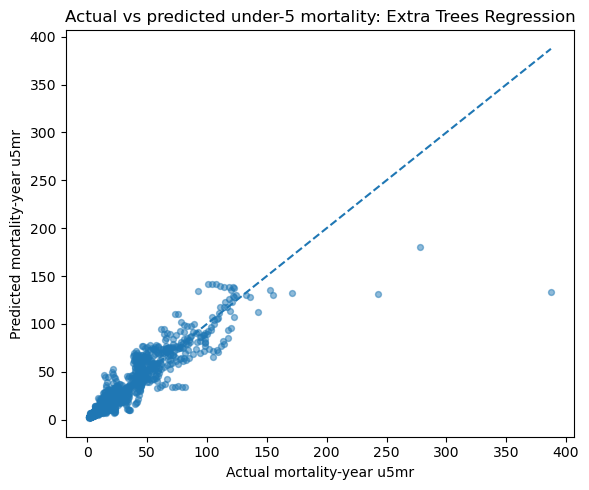

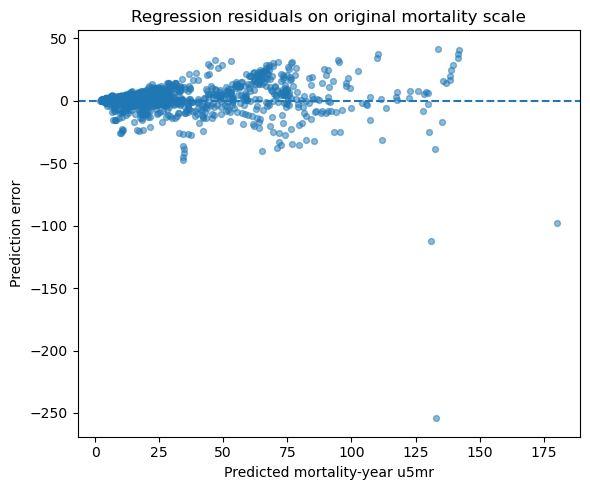

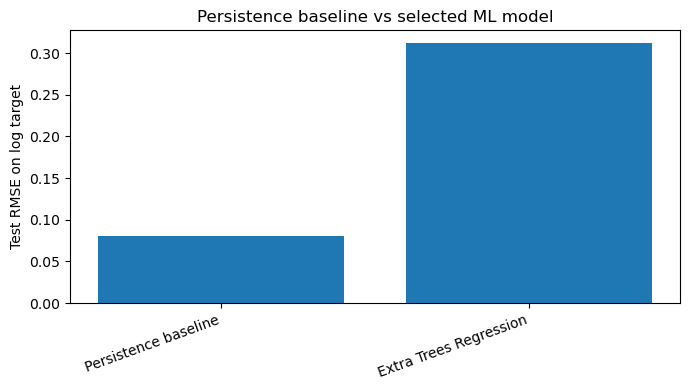

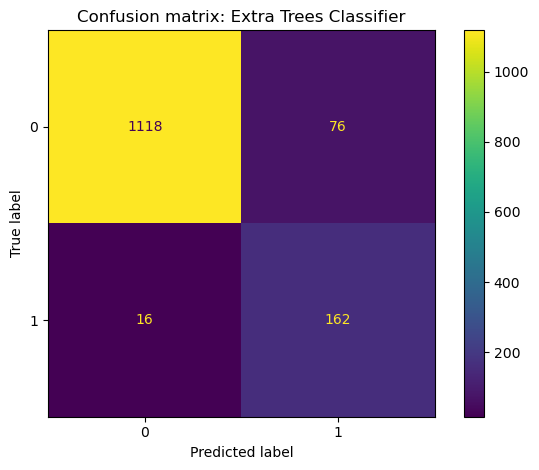

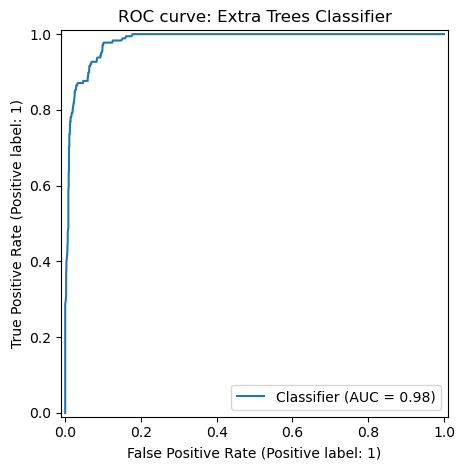

In [125]:
plt.figure(figsize=(6, 5))
plt.scatter(chrono_regression_predictions["actual_u5mr_mortality_year"], chrono_regression_predictions["predicted_u5mr_mortality_year"], alpha=0.5, s=18)
axis_min = min(chrono_regression_predictions["actual_u5mr_mortality_year"].min(), chrono_regression_predictions["predicted_u5mr_mortality_year"].min())
axis_max = max(chrono_regression_predictions["actual_u5mr_mortality_year"].max(), chrono_regression_predictions["predicted_u5mr_mortality_year"].max())
plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--")
plt.title(f"Actual vs predicted under-5 mortality: {best_regression_name}")
plt.xlabel("Actual mortality-year u5mr")
plt.ylabel("Predicted mortality-year u5mr")
plt.tight_layout()
plt.savefig(figures_dir / "regression_actual_vs_predicted.png", dpi=200)
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(chrono_regression_predictions["predicted_u5mr_mortality_year"], chrono_regression_predictions["forecast_error_u5mr"], alpha=0.5, s=18)
plt.axhline(0, linestyle="--")
plt.title("Regression residuals on original mortality scale")
plt.xlabel("Predicted mortality-year u5mr")
plt.ylabel("Prediction error")
plt.tight_layout()
plt.savefig(figures_dir / "regression_residual_plot.png", dpi=200)
plt.show()

comparison_plot_df = chrono_regression_results[chrono_regression_results["model"].isin(["Persistence baseline", best_regression_name])].copy()
plt.figure(figsize=(7, 4))
plt.bar(comparison_plot_df["model"], comparison_plot_df["test_rmse_log"])
plt.title("Persistence baseline vs selected ML model")
plt.ylabel("Test RMSE on log target")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "persistence_vs_selected_regression_model.png", dpi=200)
plt.show()

ConfusionMatrixDisplay.from_predictions(
    chrono_classification_predictions["actual_high_risk_mortality_year"],
    chrono_classification_predictions["predicted_high_risk_mortality_year"]
)
plt.title(f"Confusion matrix: {best_classification_name}")
plt.tight_layout()
plt.savefig(figures_dir / "classification_confusion_matrix.png", dpi=200)
plt.show()

if len(np.unique(chrono_classification_predictions["actual_high_risk_mortality_year"])) > 1 and len(np.unique(chrono_classification_predictions["predicted_score"])) > 1:
    RocCurveDisplay.from_predictions(
        chrono_classification_predictions["actual_high_risk_mortality_year"],
        chrono_classification_predictions["predicted_score"]
    )
    plt.title(f"ROC curve: {best_classification_name}")
    plt.tight_layout()
    plt.savefig(figures_dir / "classification_roc_curve.png", dpi=200)
    plt.show()

## Permutation Feature Importance

Permutation importance is reported for the selected regression and classification models. Because predictors are correlated, this should be interpreted as predictive importance under the fitted model, not as causal importance.

,feature,importance_mean,importance_std
0,pop_0_14_pct,0.265604,0.006743
1,sanitation_basic,0.244075,0.005417
2,log_gdp_pc,0.189661,0.004233
3,water_basic,0.079962,0.003031
4,electricity,0.069665,0.003564
5,urban_pct,0.048374,0.002669
6,fertility,0.047210,0.002399
7,health_exp_pct_gdp,0.037703,0.001952
8,dpt,0.020969,0.001818
9,measles,0.013589,0.000814


,feature,importance_mean,importance_std
0,sanitation_basic,0.122858,0.015230
1,water_basic,0.035042,0.005061
2,pop_0_14_pct,0.032400,0.004783
3,electricity,0.030898,0.006778
4,log_gdp_pc,0.022374,0.003684
5,dpt,0.020941,0.006136
6,measles,0.018628,0.003126
7,urban_pct,0.018461,0.003630
8,fertility,0.013917,0.004104
9,health_exp_pct_gdp,0.010950,0.003400


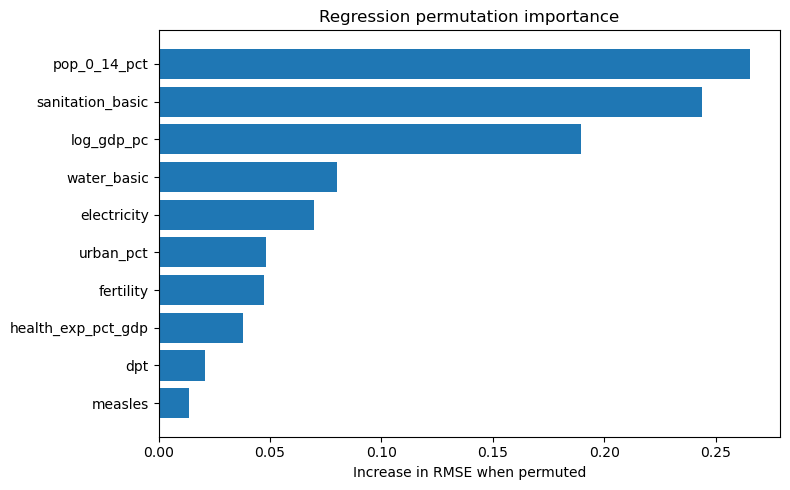

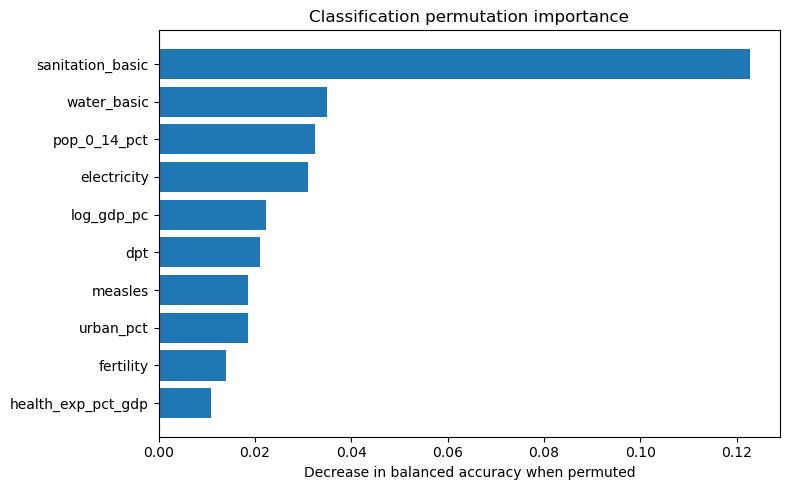

In [127]:
reg_perm = permutation_importance(
    best_regression_model,
    chrono_test_df[stage4_features],
    chrono_test_df["log_u5mr_mortality_year"],
    n_repeats=10,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

regression_importance = pd.DataFrame({
    "feature": stage4_features,
    "importance_mean": reg_perm.importances_mean,
    "importance_std": reg_perm.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

clf_perm = permutation_importance(
    best_classification_model,
    classification_test_df[stage4_features],
    classification_test_df["high_risk_mortality_year"],
    n_repeats=10,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1
)

classification_importance = pd.DataFrame({
    "feature": stage4_features,
    "importance_mean": clf_perm.importances_mean,
    "importance_std": clf_perm.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

regression_importance.to_csv(importance_dir / "regression_permutation_importance.csv", index=False)
classification_importance.to_csv(importance_dir / "classification_permutation_importance.csv", index=False)

display(regression_importance)
display(classification_importance)

plt.figure(figsize=(8, 5))
plt.barh(regression_importance["feature"].iloc[::-1], regression_importance["importance_mean"].iloc[::-1])
plt.title("Regression permutation importance")
plt.xlabel("Increase in RMSE when permuted")
plt.tight_layout()
plt.savefig(figures_dir / "regression_permutation_importance.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.barh(classification_importance["feature"].iloc[::-1], classification_importance["importance_mean"].iloc[::-1])
plt.title("Classification permutation importance")
plt.xlabel("Decrease in balanced accuracy when permuted")
plt.tight_layout()
plt.savefig(figures_dir / "classification_permutation_importance.png", dpi=200)
plt.show()

## Optional SHAP Analysis

SHAP is attempted for the selected regression model if the installed environment supports it and if the selected estimator is compatible. The notebook continues safely if SHAP is unavailable.

In [129]:
shap_status = "not run"
try:
    import shap
    if hasattr(best_regression_model.named_steps.get("model"), "feature_importances_"):
        preprocessing_steps = best_regression_model[:-1]
        regression_estimator = best_regression_model.named_steps["model"]
        X_shap_raw = chrono_test_df[stage4_features].sample(min(300, len(chrono_test_df)), random_state=42)
        X_shap_transformed = preprocessing_steps.transform(X_shap_raw)
        X_shap = pd.DataFrame(X_shap_transformed, columns=stage4_features)
        explainer = shap.TreeExplainer(regression_estimator)
        shap_values = explainer.shap_values(X_shap)
        shap.summary_plot(shap_values, X_shap, show=False)
        plt.tight_layout()
        plt.savefig(figures_dir / "regression_shap_summary.png", dpi=200, bbox_inches="tight")
        plt.show()
        shap_status = "completed"
    else:
        shap_status = "selected regression model is not tree-compatible for this SHAP cell"
except Exception as error:
    shap_status = f"not completed: {error}"

shap_audit = pd.DataFrame({"item": ["shap_status"], "value": [shap_status]})
shap_audit.to_csv(diagnostics_dir / "shap_audit.csv", index=False)
display(shap_audit)

,item,value
0,shap_status,not completed: No module named 'shap'


## Bootstrap Confidence Intervals

The intervals below quantify uncertainty in the test-set metric conditional on the fitted model. They do not capture full model-selection uncertainty.

In [131]:
rng = np.random.default_rng(42)
bootstrap_rows = []

reg_actual_log = chrono_regression_predictions["actual_log_u5mr_mortality_year"].to_numpy()
reg_pred_log = chrono_regression_predictions["predicted_log_u5mr_mortality_year"].to_numpy()
clf_actual = chrono_classification_predictions["actual_high_risk_mortality_year"].to_numpy()
clf_pred = chrono_classification_predictions["predicted_high_risk_mortality_year"].to_numpy()
clf_score = chrono_classification_predictions["predicted_score"].to_numpy()

for _ in range(1000):
    reg_idx = rng.integers(0, len(reg_actual_log), len(reg_actual_log))
    clf_idx = rng.integers(0, len(clf_actual), len(clf_actual))
    bootstrap_rows.append({
        "regression_rmse_log": rmse(reg_actual_log[reg_idx], reg_pred_log[reg_idx]),
        "classification_balanced_accuracy": balanced_accuracy_score(clf_actual[clf_idx], clf_pred[clf_idx]),
        "classification_roc_auc": safe_roc_auc(clf_actual[clf_idx], clf_score[clf_idx])
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_ci = bootstrap_df.quantile([0.025, 0.5, 0.975]).T.reset_index()
bootstrap_ci.columns = ["metric", "ci_2_5", "median", "ci_97_5"]
bootstrap_ci.to_csv(diagnostics_dir / "bootstrap_metric_confidence_intervals.csv", index=False)
display(bootstrap_ci)

,metric,ci_2_5,median,ci_97_5
0,regression_rmse_log,0.295651,0.311770,0.327333
1,classification_balanced_accuracy,0.900106,0.923688,0.944298
2,classification_roc_auc,0.975739,0.982653,0.988263


## Final Interpretation for Report

The final interpretation must be conditional and honest. The primary evidence is the chronological test. The persistence baseline is the decisive benchmark. Feature importance is predictive, not causal, because the development indicators are strongly correlated.

In [133]:
persistence_rmse = float(chrono_regression_results.loc[chrono_regression_results["model"] == "Persistence baseline", "test_rmse_log"].iloc[0])
best_regression_rmse = float(chrono_regression_results.loc[chrono_regression_results["model"] == best_regression_name, "test_rmse_log"].iloc[0])
beats_persistence = best_regression_rmse < persistence_rmse

top_regression_feature = regression_importance.iloc[0]["feature"]
top_classification_feature = classification_importance.iloc[0]["feature"]
high_vif_features = ", ".join(vif_table.loc[vif_table["vif"] > 10, "feature"].tolist())

final_interpretation_summary = pd.DataFrame({
    "item": [
        "selected_regression_model",
        "selected_classification_model",
        "regression_beats_persistence_baseline",
        "persistence_test_rmse_log",
        "selected_regression_test_rmse_log",
        "selected_regression_test_r2_log",
        "selected_regression_original_scale_mae",
        "classification_test_balanced_accuracy",
        "classification_test_roc_auc",
        "top_regression_feature_by_permutation",
        "top_classification_feature_by_permutation",
        "features_with_vif_above_10",
        "fixed_effects_robustness_r2",
        "main_limitation"
    ],
    "value": [
        best_regression_name,
        best_classification_name,
        beats_persistence,
        persistence_rmse,
        best_regression_rmse,
        float(chrono_regression_results.loc[chrono_regression_results["model"] == best_regression_name, "test_r2_log"].iloc[0]),
        float(chrono_regression_results.loc[chrono_regression_results["model"] == best_regression_name, "test_mae_original_u5mr"].iloc[0]),
        float(chrono_classification_results.loc[chrono_classification_results["model"] == best_classification_name, "test_balanced_accuracy"].iloc[0]),
        float(chrono_classification_results.loc[chrono_classification_results["model"] == best_classification_name, "test_roc_auc"].iloc[0]),
        top_regression_feature,
        top_classification_feature,
        high_vif_features if high_vif_features else "none above 10",
        float(fixed_effects_results["test_r2_within_log"].iloc[0]),
        "The pooled model may rely strongly on persistent cross-country differences; fixed-effects and persistence-baseline results must be reported alongside main metrics."
    ]
})

final_interpretation_summary.to_csv(summary_dir / "final_interpretation_summary.csv", index=False)
display(final_interpretation_summary)

,item,value
0,selected_regression_model,Extra Trees Regression
1,selected_classification_model,Extra Trees Classifier
2,regression_beats_persistence_baseline,False
3,persistence_test_rmse_log,0.080872
4,selected_regression_test_rmse_log,0.311648
5,selected_regression_test_r2_log,0.919101
6,selected_regression_original_scale_mae,6.082467
7,classification_test_balanced_accuracy,0.92323
8,classification_test_roc_auc,0.982556
9,top_regression_feature_by_permutation,pop_0_14_pct


---

# Final Conclusion

This final version supports a more careful claim than earlier drafts. The model is evaluated as a chronological mortality-year prediction system, not merely as a random country-year classifier. The central benchmark is the persistence baseline, because under-5 mortality changes slowly over time. The selected ML model should be considered useful only to the extent that it improves on this baseline.

Predictor imputation is performed inside the model pipelines using training data only, so the evaluation no longer relies on a globally filtered complete-case sample. The fixed-effect robustness check clarifies how much of the pooled performance reflects persistent country differences rather than within-country dynamics. Feature importance is reported as predictive association, not causal effect, because many development indicators are highly collinear.

The historical train-test stage is a backtest, not the real forecast. The real forecast uses 2023 predictor values to estimate 2024 under-5 mortality and high-risk status.
